In [ ]:
#CGAN MODEL
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import random
import math
from torch.utils.data import DataLoader, Dataset
# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Load and preprocess the data
data = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/Material2_Train_6cases.csv')

SENSOR_FEATURES = [
    'vib_spindle_rms', 'vib_spindle_mean', 'vib_spindle_peak',
    'AE_table_mag_centroid', 'smcAC_shape', 'vib_table_skewness',
    'vib_spindle_mag_centroid', 'AE_table_peak'
]

def normalize_features(df):
    min_doc, max_doc = 0.75, 1.5
    min_feed, max_feed = 0.25, 0.5
    min_time, max_time = 0, int(df['time'].max())
    df_normalized = df.copy()
    df_normalized['DOC'] = (df['DOC'] - min_doc) / (max_doc - min_doc)
    df_normalized['feed'] = (df['feed'] - min_feed) / (max_feed - min_feed)
    df_normalized['time'] = (df['time'] - min_time) / (max_time - min_time)
    for feature in SENSOR_FEATURES:
        min_val = df[feature].min()
        max_val = df[feature].max()
        df_normalized[feature] = (df[feature] - min_val) / (max_val - min_val)
    return df_normalized, {
        'time': (min_time, max_time),
        'sensor_ranges': {feature: (df[feature].min(), df[feature].max()) for feature in SENSOR_FEATURES}
    }

normalized_data, feature_ranges = normalize_features(data)

class ToolWearDataset(Dataset):
    def __init__(self, data):
        self.data = data
        self.wear_classes = ['fresh', 'earlyworn', 'midworn', 'worn', 'highworn', 'fail']

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        features = torch.tensor([row['DOC'], row['feed'], row['time']] +
                              [row[feature] for feature in SENSOR_FEATURES], dtype=torch.float)
        wear_class = row['VB_class']
        condition = torch.zeros(6)
        condition[self.wear_classes.index(wear_class)] = 1
        return features, condition

class Generator(nn.Module):
    def __init__(self, latent_dim, condition_dim):
        super(Generator, self).__init__()
        def block(in_feat, out_feat):
            return [nn.Linear(in_feat, out_feat), nn.LeakyReLU(0.2), nn.BatchNorm1d(out_feat, 0.8)]
        self.model = nn.Sequential(
            *block(latent_dim + condition_dim, 512),
            *block(512, 1024),
            *block(1024, 512),
            *block(512, 256),
            nn.Linear(256, 11),
            nn.Sigmoid()
        )

    def forward(self, noise, labels):
        x = torch.cat((noise, labels), -1)
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, feature_dim, condition_dim):
        super(Discriminator, self).__init__()
        def block(in_feat, out_feat):
            return [nn.Linear(in_feat, out_feat), nn.LeakyReLU(0.2), nn.Dropout(0.3)]
        self.model = nn.Sequential(
            *block(feature_dim + condition_dim, 512),
            *block(512, 512),
            *block(512, 256),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, features, labels):
        x = torch.cat((features, labels), -1)
        return self.model(x)

latent_dim = 128
condition_dim = 8  # 6 class + 2 (doc, feed)
feature_dim = 11
batch_size = 32
num_epochs = 3000

generator = Generator(latent_dim, condition_dim)
discriminator = Discriminator(feature_dim, condition_dim)

criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

dataset = ToolWearDataset(normalized_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

def train_cgan():
    for epoch in range(num_epochs):
        for i, (real_features, labels) in enumerate(dataloader):
            batch_size = real_features.size(0)
            valid = torch.ones(batch_size, 1)
            fake = torch.zeros(batch_size, 1)

            g_optimizer.zero_grad()
            z = torch.randn(batch_size, latent_dim)
            doc = torch.rand(batch_size, 1)
            feed = torch.rand(batch_size, 1)
            full_cond = torch.cat((labels, doc, feed), dim=1)
            gen_features = generator(z, full_cond)
            validity = discriminator(gen_features, full_cond)
            g_loss = criterion(validity, valid)
            g_loss.backward()
            g_optimizer.step()

            d_optimizer.zero_grad()
            validity_real = discriminator(real_features, full_cond)
            d_real_loss = criterion(validity_real, valid)
            validity_fake = discriminator(gen_features.detach(), full_cond)
            d_fake_loss = criterion(validity_fake, fake)
            d_loss = (d_real_loss + d_fake_loss) / 2
            d_loss.backward()
            d_optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{num_epochs} | D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

def generate_synthetic_data(num_combinations=15):
    generator.eval()
    synthetic_data = []
    wear_classes = ['fresh', 'earlyworn', 'midworn', 'worn', 'highworn', 'fail']
    class_ranges = {'fresh': (0, 2), 'earlyworn': (0, 2), 'midworn': (0, 3),
                    'worn': (0, 1), 'highworn': (0, 1), 'fail': (1, 2)}

    for i in range(num_combinations):
        doc = round(np.random.uniform(0.75, 1.5), 2)
        feed = round(np.random.uniform(0.25, 0.5), 2)
        doc_norm = (doc - 0.75) / (1.5 - 0.75)
        feed_norm = (feed - 0.25) / (0.5 - 0.25)
        class_idx = random.randint(0, 5)
        condition = torch.zeros(1, 6)
        condition[0, class_idx] = 1
        full_condition = torch.cat((condition, torch.tensor([[doc_norm, feed_norm]])), dim=1)
        z = torch.randn(1, latent_dim)
        with torch.no_grad():
            generated = generator(z, full_condition).numpy()[0]

        num_runs = random.randint(8,12)
        max_case_time = random.randint(15, 50)
        class_counts = {'fail': random.randint(1, 2)}
        remaining_runs = num_runs - class_counts['fail']
        for cls in wear_classes[:-1]:
            if remaining_runs <= 0:
                class_counts[cls] = 0
                continue
            min_c, max_c = class_ranges[cls]
            count = random.randint(min_c, min(max_c, remaining_runs))
            class_counts[cls] = count
            remaining_runs -= count

        sensor_values = {}
        for idx, feature in enumerate(SENSOR_FEATURES):
            min_val, max_val = feature_ranges['sensor_ranges'][feature]
            sensor_values[feature] = generated[idx + 3] * (max_val - min_val) + min_val

        run_counter, current_time = 1, 0
        time_step = max_case_time // (num_runs - 1) if num_runs > 1 else max_case_time
        ordered_classes = [cls for cls in wear_classes for _ in range(class_counts[cls])]

        for wear_class in ordered_classes:
            row = {
                'case': i + 1,
                'run': run_counter,
                'DOC': doc,
                'feed': feed,
                'time': current_time,
                'VB_class': wear_class
            }
            for f, v in sensor_values.items():
                variation = np.random.uniform(-0.05, 0.05) * v
                row[f] = round(v + variation, 6)
            synthetic_data.append(row)
            run_counter += 1
            current_time += time_step

    return pd.DataFrame(synthetic_data)

print("Training CGAN...")
train_cgan()

print("Generating synthetic data...")
syn_df = generate_synthetic_data(15)
syn_df.to_csv('synthetic_data_mat2_15.csv', index=False)

print("Saved synthetic data to synthetic_data_mat2_15.csv")

Training CGAN...
Epoch 0/3000 | D Loss: 0.6938, G Loss: 0.6657
Epoch 100/3000 | D Loss: 0.6744, G Loss: 0.6173
Epoch 200/3000 | D Loss: 0.5729, G Loss: 0.9679
Epoch 300/3000 | D Loss: 0.5530, G Loss: 0.8782
Epoch 400/3000 | D Loss: 0.8559, G Loss: 0.6996
Epoch 500/3000 | D Loss: 0.6746, G Loss: 1.3585
Epoch 600/3000 | D Loss: 0.6159, G Loss: 0.8266
Epoch 700/3000 | D Loss: 0.4606, G Loss: 1.1167
Epoch 800/3000 | D Loss: 0.5409, G Loss: 1.0717
Epoch 900/3000 | D Loss: 0.7231, G Loss: 0.9673
Epoch 1000/3000 | D Loss: 0.5653, G Loss: 0.9080
Epoch 1100/3000 | D Loss: 0.6417, G Loss: 1.2042
Epoch 1200/3000 | D Loss: 0.6866, G Loss: 1.4245
Epoch 1300/3000 | D Loss: 0.4781, G Loss: 1.2260
Epoch 1400/3000 | D Loss: 0.6924, G Loss: 1.2240
Epoch 1500/3000 | D Loss: 0.5296, G Loss: 0.8797
Epoch 1600/3000 | D Loss: 0.5620, G Loss: 1.3910
Epoch 1700/3000 | D Loss: 0.5585, G Loss: 1.1360
Epoch 1800/3000 | D Loss: 0.5325, G Loss: 0.7258
Epoch 1900/3000 | D Loss: 0.6134, G Loss: 0.9298
Epoch 2000/3000

In [ ]:
#CGAN MODEL
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import random
import math
from torch.utils.data import DataLoader, Dataset
# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Load and preprocess the data
data = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/Material2_Train_6cases.csv')

SENSOR_FEATURES = [
    'vib_spindle_rms', 'vib_spindle_mean', 'vib_spindle_peak',
    'AE_table_mag_centroid', 'smcAC_shape', 'vib_table_skewness',
    'vib_spindle_mag_centroid', 'AE_table_peak'
]

def normalize_features(df):
    min_doc, max_doc = 0.75, 1.5
    min_feed, max_feed = 0.25, 0.5
    min_time, max_time = 0, int(df['time'].max())
    df_normalized = df.copy()
    df_normalized['DOC'] = (df['DOC'] - min_doc) / (max_doc - min_doc)
    df_normalized['feed'] = (df['feed'] - min_feed) / (max_feed - min_feed)
    df_normalized['time'] = (df['time'] - min_time) / (max_time - min_time)
    for feature in SENSOR_FEATURES:
        min_val = df[feature].min()
        max_val = df[feature].max()
        df_normalized[feature] = (df[feature] - min_val) / (max_val - min_val)
    return df_normalized, {
        'time': (min_time, max_time),
        'sensor_ranges': {feature: (df[feature].min(), df[feature].max()) for feature in SENSOR_FEATURES}
    }

normalized_data, feature_ranges = normalize_features(data)

class ToolWearDataset(Dataset):
    def __init__(self, data):
        self.data = data
        self.wear_classes = ['fresh', 'earlyworn', 'midworn', 'worn', 'highworn', 'fail']

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        features = torch.tensor([row['DOC'], row['feed'], row['time']] +
                              [row[feature] for feature in SENSOR_FEATURES], dtype=torch.float)
        wear_class = row['VB_class']
        condition = torch.zeros(6)
        condition[self.wear_classes.index(wear_class)] = 1
        return features, condition

class Generator(nn.Module):
    def __init__(self, latent_dim, condition_dim):
        super(Generator, self).__init__()
        def block(in_feat, out_feat):
            return [nn.Linear(in_feat, out_feat), nn.LeakyReLU(0.2), nn.BatchNorm1d(out_feat, 0.8)]
        self.model = nn.Sequential(
            *block(latent_dim + condition_dim, 512),
            *block(512, 1024),
            *block(1024, 512),
            *block(512, 256),
            nn.Linear(256, 11),
            nn.Sigmoid()
        )

    def forward(self, noise, labels):
        x = torch.cat((noise, labels), -1)
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, feature_dim, condition_dim):
        super(Discriminator, self).__init__()
        def block(in_feat, out_feat):
            return [nn.Linear(in_feat, out_feat), nn.LeakyReLU(0.2), nn.Dropout(0.3)]
        self.model = nn.Sequential(
            *block(feature_dim + condition_dim, 512),
            *block(512, 512),
            *block(512, 256),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, features, labels):
        x = torch.cat((features, labels), -1)
        return self.model(x)

latent_dim = 128
condition_dim = 8  # 6 class + 2 (doc, feed)
feature_dim = 11
batch_size = 32
num_epochs = 3000

generator = Generator(latent_dim, condition_dim)
discriminator = Discriminator(feature_dim, condition_dim)

criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

dataset = ToolWearDataset(normalized_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

def train_cgan():
    for epoch in range(num_epochs):
        for i, (real_features, labels) in enumerate(dataloader):
            batch_size = real_features.size(0)
            valid = torch.ones(batch_size, 1)
            fake = torch.zeros(batch_size, 1)

            g_optimizer.zero_grad()
            z = torch.randn(batch_size, latent_dim)
            doc = torch.rand(batch_size, 1)
            feed = torch.rand(batch_size, 1)
            full_cond = torch.cat((labels, doc, feed), dim=1)
            gen_features = generator(z, full_cond)
            validity = discriminator(gen_features, full_cond)
            g_loss = criterion(validity, valid)
            g_loss.backward()
            g_optimizer.step()

            d_optimizer.zero_grad()
            validity_real = discriminator(real_features, full_cond)
            d_real_loss = criterion(validity_real, valid)
            validity_fake = discriminator(gen_features.detach(), full_cond)
            d_fake_loss = criterion(validity_fake, fake)
            d_loss = (d_real_loss + d_fake_loss) / 2
            d_loss.backward()
            d_optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{num_epochs} | D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

def generate_synthetic_data(num_combinations=10):
    generator.eval()
    synthetic_data = []
    wear_classes = ['fresh', 'earlyworn', 'midworn', 'worn', 'highworn', 'fail']
    class_ranges = {'fresh': (0, 2), 'earlyworn': (0, 2), 'midworn': (0, 3),
                    'worn': (0, 1), 'highworn': (0, 1), 'fail': (1, 2)}

    for i in range(num_combinations):
        doc = round(np.random.uniform(0.75, 1.5), 2)
        feed = round(np.random.uniform(0.25, 0.5), 2)
        doc_norm = (doc - 0.75) / (1.5 - 0.75)
        feed_norm = (feed - 0.25) / (0.5 - 0.25)
        class_idx = random.randint(0, 5)
        condition = torch.zeros(1, 6)
        condition[0, class_idx] = 1
        full_condition = torch.cat((condition, torch.tensor([[doc_norm, feed_norm]])), dim=1)
        z = torch.randn(1, latent_dim)
        with torch.no_grad():
            generated = generator(z, full_condition).numpy()[0]

        num_runs = random.randint(8,12)
        max_case_time = random.randint(15, 50)
        class_counts = {'fail': random.randint(1, 2)}
        remaining_runs = num_runs - class_counts['fail']
        for cls in wear_classes[:-1]:
            if remaining_runs <= 0:
                class_counts[cls] = 0
                continue
            min_c, max_c = class_ranges[cls]
            count = random.randint(min_c, min(max_c, remaining_runs))
            class_counts[cls] = count
            remaining_runs -= count

        sensor_values = {}
        for idx, feature in enumerate(SENSOR_FEATURES):
            min_val, max_val = feature_ranges['sensor_ranges'][feature]
            sensor_values[feature] = generated[idx + 3] * (max_val - min_val) + min_val

        run_counter, current_time = 1, 0
        time_step = max_case_time // (num_runs - 1) if num_runs > 1 else max_case_time
        ordered_classes = [cls for cls in wear_classes for _ in range(class_counts[cls])]

        for wear_class in ordered_classes:
            row = {
                'case': i + 1,
                'run': run_counter,
                'DOC': doc,
                'feed': feed,
                'time': current_time,
                'VB_class': wear_class
            }
            for f, v in sensor_values.items():
                variation = np.random.uniform(-0.05, 0.05) * v
                row[f] = round(v + variation, 6)
            synthetic_data.append(row)
            run_counter += 1
            current_time += time_step

    return pd.DataFrame(synthetic_data)

print("Training CGAN...")
train_cgan()

print("Generating synthetic data...")
syn_df = generate_synthetic_data(10)
syn_df.to_csv('synthetic_data_mat2_10.csv', index=False)

print("Saved synthetic data to synthetic_data_mat2_10.csv")

Training CGAN...
Epoch 0/3000 | D Loss: 0.6938, G Loss: 0.6657
Epoch 100/3000 | D Loss: 0.6744, G Loss: 0.6173
Epoch 200/3000 | D Loss: 0.5729, G Loss: 0.9679
Epoch 300/3000 | D Loss: 0.5530, G Loss: 0.8782
Epoch 400/3000 | D Loss: 0.8559, G Loss: 0.6996
Epoch 500/3000 | D Loss: 0.6746, G Loss: 1.3585
Epoch 600/3000 | D Loss: 0.6159, G Loss: 0.8266
Epoch 700/3000 | D Loss: 0.4606, G Loss: 1.1167
Epoch 800/3000 | D Loss: 0.5409, G Loss: 1.0717
Epoch 900/3000 | D Loss: 0.7231, G Loss: 0.9673
Epoch 1000/3000 | D Loss: 0.5653, G Loss: 0.9080
Epoch 1100/3000 | D Loss: 0.6417, G Loss: 1.2042
Epoch 1200/3000 | D Loss: 0.6866, G Loss: 1.4245
Epoch 1300/3000 | D Loss: 0.4781, G Loss: 1.2260
Epoch 1400/3000 | D Loss: 0.6924, G Loss: 1.2240
Epoch 1500/3000 | D Loss: 0.5296, G Loss: 0.8797
Epoch 1600/3000 | D Loss: 0.5620, G Loss: 1.3910
Epoch 1700/3000 | D Loss: 0.5585, G Loss: 1.1360
Epoch 1800/3000 | D Loss: 0.5325, G Loss: 0.7258
Epoch 1900/3000 | D Loss: 0.6134, G Loss: 0.9298
Epoch 2000/3000

In [ ]:
#CGAN MODEL
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import random
import math
from torch.utils.data import DataLoader, Dataset
# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Load and preprocess the data
data = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/Material2_Train_6cases.csv')

SENSOR_FEATURES = [
    'vib_spindle_rms', 'vib_spindle_mean', 'vib_spindle_peak',
    'AE_table_mag_centroid', 'smcAC_shape', 'vib_table_skewness',
    'vib_spindle_mag_centroid', 'AE_table_peak'
]

def normalize_features(df):
    min_doc, max_doc = 0.75, 1.5
    min_feed, max_feed = 0.25, 0.5
    min_time, max_time = 0, int(df['time'].max())
    df_normalized = df.copy()
    df_normalized['DOC'] = (df['DOC'] - min_doc) / (max_doc - min_doc)
    df_normalized['feed'] = (df['feed'] - min_feed) / (max_feed - min_feed)
    df_normalized['time'] = (df['time'] - min_time) / (max_time - min_time)
    for feature in SENSOR_FEATURES:
        min_val = df[feature].min()
        max_val = df[feature].max()
        df_normalized[feature] = (df[feature] - min_val) / (max_val - min_val)
    return df_normalized, {
        'time': (min_time, max_time),
        'sensor_ranges': {feature: (df[feature].min(), df[feature].max()) for feature in SENSOR_FEATURES}
    }

normalized_data, feature_ranges = normalize_features(data)

class ToolWearDataset(Dataset):
    def __init__(self, data):
        self.data = data
        self.wear_classes = ['fresh', 'earlyworn', 'midworn', 'worn', 'highworn', 'fail']

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        features = torch.tensor([row['DOC'], row['feed'], row['time']] +
                              [row[feature] for feature in SENSOR_FEATURES], dtype=torch.float)
        wear_class = row['VB_class']
        condition = torch.zeros(6)
        condition[self.wear_classes.index(wear_class)] = 1
        return features, condition

class Generator(nn.Module):
    def __init__(self, latent_dim, condition_dim):
        super(Generator, self).__init__()
        def block(in_feat, out_feat):
            return [nn.Linear(in_feat, out_feat), nn.LeakyReLU(0.2), nn.BatchNorm1d(out_feat, 0.8)]
        self.model = nn.Sequential(
            *block(latent_dim + condition_dim, 512),
            *block(512, 1024),
            *block(1024, 512),
            *block(512, 256),
            nn.Linear(256, 11),
            nn.Sigmoid()
        )

    def forward(self, noise, labels):
        x = torch.cat((noise, labels), -1)
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, feature_dim, condition_dim):
        super(Discriminator, self).__init__()
        def block(in_feat, out_feat):
            return [nn.Linear(in_feat, out_feat), nn.LeakyReLU(0.2), nn.Dropout(0.3)]
        self.model = nn.Sequential(
            *block(feature_dim + condition_dim, 512),
            *block(512, 512),
            *block(512, 256),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, features, labels):
        x = torch.cat((features, labels), -1)
        return self.model(x)

latent_dim = 128
condition_dim = 8  # 6 class + 2 (doc, feed)
feature_dim = 11
batch_size = 32
num_epochs = 3000

generator = Generator(latent_dim, condition_dim)
discriminator = Discriminator(feature_dim, condition_dim)

criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

dataset = ToolWearDataset(normalized_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

def train_cgan():
    for epoch in range(num_epochs):
        for i, (real_features, labels) in enumerate(dataloader):
            batch_size = real_features.size(0)
            valid = torch.ones(batch_size, 1)
            fake = torch.zeros(batch_size, 1)

            g_optimizer.zero_grad()
            z = torch.randn(batch_size, latent_dim)
            doc = torch.rand(batch_size, 1)
            feed = torch.rand(batch_size, 1)
            full_cond = torch.cat((labels, doc, feed), dim=1)
            gen_features = generator(z, full_cond)
            validity = discriminator(gen_features, full_cond)
            g_loss = criterion(validity, valid)
            g_loss.backward()
            g_optimizer.step()

            d_optimizer.zero_grad()
            validity_real = discriminator(real_features, full_cond)
            d_real_loss = criterion(validity_real, valid)
            validity_fake = discriminator(gen_features.detach(), full_cond)
            d_fake_loss = criterion(validity_fake, fake)
            d_loss = (d_real_loss + d_fake_loss) / 2
            d_loss.backward()
            d_optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{num_epochs} | D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

def generate_synthetic_data(num_combinations=30):
    generator.eval()
    synthetic_data = []
    wear_classes = ['fresh', 'earlyworn', 'midworn', 'worn', 'highworn', 'fail']
    class_ranges = {'fresh': (0, 2), 'earlyworn': (0, 2), 'midworn': (0, 3),
                    'worn': (0, 1), 'highworn': (0, 1), 'fail': (1, 2)}

    for i in range(num_combinations):
        doc = round(np.random.uniform(0.75, 1.5), 2)
        feed = round(np.random.uniform(0.25, 0.5), 2)
        doc_norm = (doc - 0.75) / (1.5 - 0.75)
        feed_norm = (feed - 0.25) / (0.5 - 0.25)
        class_idx = random.randint(0, 5)
        condition = torch.zeros(1, 6)
        condition[0, class_idx] = 1
        full_condition = torch.cat((condition, torch.tensor([[doc_norm, feed_norm]])), dim=1)
        z = torch.randn(1, latent_dim)
        with torch.no_grad():
            generated = generator(z, full_condition).numpy()[0]

        num_runs = random.randint(8,12)
        max_case_time = random.randint(15, 50)
        class_counts = {'fail': random.randint(1, 2)}
        remaining_runs = num_runs - class_counts['fail']
        for cls in wear_classes[:-1]:
            if remaining_runs <= 0:
                class_counts[cls] = 0
                continue
            min_c, max_c = class_ranges[cls]
            count = random.randint(min_c, min(max_c, remaining_runs))
            class_counts[cls] = count
            remaining_runs -= count

        sensor_values = {}
        for idx, feature in enumerate(SENSOR_FEATURES):
            min_val, max_val = feature_ranges['sensor_ranges'][feature]
            sensor_values[feature] = generated[idx + 3] * (max_val - min_val) + min_val

        run_counter, current_time = 1, 0
        time_step = max_case_time // (num_runs - 1) if num_runs > 1 else max_case_time
        ordered_classes = [cls for cls in wear_classes for _ in range(class_counts[cls])]

        for wear_class in ordered_classes:
            row = {
                'case': i + 1,
                'run': run_counter,
                'DOC': doc,
                'feed': feed,
                'time': current_time,
                'VB_class': wear_class
            }
            for f, v in sensor_values.items():
                variation = np.random.uniform(-0.05, 0.05) * v
                row[f] = round(v + variation, 6)
            synthetic_data.append(row)
            run_counter += 1
            current_time += time_step

    return pd.DataFrame(synthetic_data)

print("Training CGAN...")
train_cgan()

print("Generating synthetic data...")
syn_df = generate_synthetic_data(30)
syn_df.to_csv('synthetic_data_mat2_30.csv', index=False)

print("Saved synthetic data to synthetic_data_mat2_30.csv")

Training CGAN...
Epoch 0/3000 | D Loss: 0.6938, G Loss: 0.6657
Epoch 100/3000 | D Loss: 0.6744, G Loss: 0.6173
Epoch 200/3000 | D Loss: 0.5729, G Loss: 0.9679
Epoch 300/3000 | D Loss: 0.5530, G Loss: 0.8782
Epoch 400/3000 | D Loss: 0.8559, G Loss: 0.6996
Epoch 500/3000 | D Loss: 0.6746, G Loss: 1.3585
Epoch 600/3000 | D Loss: 0.6159, G Loss: 0.8266
Epoch 700/3000 | D Loss: 0.4606, G Loss: 1.1167
Epoch 800/3000 | D Loss: 0.5409, G Loss: 1.0717
Epoch 900/3000 | D Loss: 0.7231, G Loss: 0.9673
Epoch 1000/3000 | D Loss: 0.5653, G Loss: 0.9080
Epoch 1100/3000 | D Loss: 0.6417, G Loss: 1.2042
Epoch 1200/3000 | D Loss: 0.6866, G Loss: 1.4245
Epoch 1300/3000 | D Loss: 0.4781, G Loss: 1.2260
Epoch 1400/3000 | D Loss: 0.6924, G Loss: 1.2240
Epoch 1500/3000 | D Loss: 0.5296, G Loss: 0.8797
Epoch 1600/3000 | D Loss: 0.5620, G Loss: 1.3910
Epoch 1700/3000 | D Loss: 0.5585, G Loss: 1.1360
Epoch 1800/3000 | D Loss: 0.5325, G Loss: 0.7258
Epoch 1900/3000 | D Loss: 0.6134, G Loss: 0.9298
Epoch 2000/3000

In [ ]:
#CGAN MODEL
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import random
import math
from torch.utils.data import DataLoader, Dataset
# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Load and preprocess the data
data = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/Material2_Train_6cases.csv')

SENSOR_FEATURES = [
    'vib_spindle_rms', 'vib_spindle_mean', 'vib_spindle_peak',
    'AE_table_mag_centroid', 'smcAC_shape', 'vib_table_skewness',
    'vib_spindle_mag_centroid', 'AE_table_peak'
]

def normalize_features(df):
    min_doc, max_doc = 0.75, 1.5
    min_feed, max_feed = 0.25, 0.5
    min_time, max_time = 0, int(df['time'].max())
    df_normalized = df.copy()
    df_normalized['DOC'] = (df['DOC'] - min_doc) / (max_doc - min_doc)
    df_normalized['feed'] = (df['feed'] - min_feed) / (max_feed - min_feed)
    df_normalized['time'] = (df['time'] - min_time) / (max_time - min_time)
    for feature in SENSOR_FEATURES:
        min_val = df[feature].min()
        max_val = df[feature].max()
        df_normalized[feature] = (df[feature] - min_val) / (max_val - min_val)
    return df_normalized, {
        'time': (min_time, max_time),
        'sensor_ranges': {feature: (df[feature].min(), df[feature].max()) for feature in SENSOR_FEATURES}
    }

normalized_data, feature_ranges = normalize_features(data)

class ToolWearDataset(Dataset):
    def __init__(self, data):
        self.data = data
        self.wear_classes = ['fresh', 'earlyworn', 'midworn', 'worn', 'highworn', 'fail']

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        features = torch.tensor([row['DOC'], row['feed'], row['time']] +
                              [row[feature] for feature in SENSOR_FEATURES], dtype=torch.float)
        wear_class = row['VB_class']
        condition = torch.zeros(6)
        condition[self.wear_classes.index(wear_class)] = 1
        return features, condition

class Generator(nn.Module):
    def __init__(self, latent_dim, condition_dim):
        super(Generator, self).__init__()
        def block(in_feat, out_feat):
            return [nn.Linear(in_feat, out_feat), nn.LeakyReLU(0.2), nn.BatchNorm1d(out_feat, 0.8)]
        self.model = nn.Sequential(
            *block(latent_dim + condition_dim, 512),
            *block(512, 1024),
            *block(1024, 512),
            *block(512, 256),
            nn.Linear(256, 11),
            nn.Sigmoid()
        )

    def forward(self, noise, labels):
        x = torch.cat((noise, labels), -1)
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, feature_dim, condition_dim):
        super(Discriminator, self).__init__()
        def block(in_feat, out_feat):
            return [nn.Linear(in_feat, out_feat), nn.LeakyReLU(0.2), nn.Dropout(0.3)]
        self.model = nn.Sequential(
            *block(feature_dim + condition_dim, 512),
            *block(512, 512),
            *block(512, 256),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, features, labels):
        x = torch.cat((features, labels), -1)
        return self.model(x)

latent_dim = 128
condition_dim = 8  # 6 class + 2 (doc, feed)
feature_dim = 11
batch_size = 32
num_epochs = 3000

generator = Generator(latent_dim, condition_dim)
discriminator = Discriminator(feature_dim, condition_dim)

criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

dataset = ToolWearDataset(normalized_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

def train_cgan():
    for epoch in range(num_epochs):
        for i, (real_features, labels) in enumerate(dataloader):
            batch_size = real_features.size(0)
            valid = torch.ones(batch_size, 1)
            fake = torch.zeros(batch_size, 1)

            g_optimizer.zero_grad()
            z = torch.randn(batch_size, latent_dim)
            doc = torch.rand(batch_size, 1)
            feed = torch.rand(batch_size, 1)
            full_cond = torch.cat((labels, doc, feed), dim=1)
            gen_features = generator(z, full_cond)
            validity = discriminator(gen_features, full_cond)
            g_loss = criterion(validity, valid)
            g_loss.backward()
            g_optimizer.step()

            d_optimizer.zero_grad()
            validity_real = discriminator(real_features, full_cond)
            d_real_loss = criterion(validity_real, valid)
            validity_fake = discriminator(gen_features.detach(), full_cond)
            d_fake_loss = criterion(validity_fake, fake)
            d_loss = (d_real_loss + d_fake_loss) / 2
            d_loss.backward()
            d_optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{num_epochs} | D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

def generate_synthetic_data(num_combinations=40):
    generator.eval()
    synthetic_data = []
    wear_classes = ['fresh', 'earlyworn', 'midworn', 'worn', 'highworn', 'fail']
    class_ranges = {'fresh': (0, 2), 'earlyworn': (0, 2), 'midworn': (0, 3),
                    'worn': (0, 1), 'highworn': (0, 1), 'fail': (1, 2)}

    for i in range(num_combinations):
        doc = round(np.random.uniform(0.75, 1.5), 2)
        feed = round(np.random.uniform(0.25, 0.5), 2)
        doc_norm = (doc - 0.75) / (1.5 - 0.75)
        feed_norm = (feed - 0.25) / (0.5 - 0.25)
        class_idx = random.randint(0, 5)
        condition = torch.zeros(1, 6)
        condition[0, class_idx] = 1
        full_condition = torch.cat((condition, torch.tensor([[doc_norm, feed_norm]])), dim=1)
        z = torch.randn(1, latent_dim)
        with torch.no_grad():
            generated = generator(z, full_condition).numpy()[0]

        num_runs = random.randint(8,12)
        max_case_time = random.randint(15, 50)
        class_counts = {'fail': random.randint(1, 2)}
        remaining_runs = num_runs - class_counts['fail']
        for cls in wear_classes[:-1]:
            if remaining_runs <= 0:
                class_counts[cls] = 0
                continue
            min_c, max_c = class_ranges[cls]
            count = random.randint(min_c, min(max_c, remaining_runs))
            class_counts[cls] = count
            remaining_runs -= count

        sensor_values = {}
        for idx, feature in enumerate(SENSOR_FEATURES):
            min_val, max_val = feature_ranges['sensor_ranges'][feature]
            sensor_values[feature] = generated[idx + 3] * (max_val - min_val) + min_val

        run_counter, current_time = 1, 0
        time_step = max_case_time // (num_runs - 1) if num_runs > 1 else max_case_time
        ordered_classes = [cls for cls in wear_classes for _ in range(class_counts[cls])]

        for wear_class in ordered_classes:
            row = {
                'case': i + 1,
                'run': run_counter,
                'DOC': doc,
                'feed': feed,
                'time': current_time,
                'VB_class': wear_class
            }
            for f, v in sensor_values.items():
                variation = np.random.uniform(-0.05, 0.05) * v
                row[f] = round(v + variation, 6)
            synthetic_data.append(row)
            run_counter += 1
            current_time += time_step

    return pd.DataFrame(synthetic_data)

print("Training CGAN...")
train_cgan()

print("Generating synthetic data...")
syn_df = generate_synthetic_data(40)
syn_df.to_csv('synthetic_data_mat2_40.csv', index=False)

print("Saved synthetic data to synthetic_data_mat2_40.csv")

Training CGAN...
Epoch 0/3000 | D Loss: 0.6938, G Loss: 0.6657
Epoch 100/3000 | D Loss: 0.6744, G Loss: 0.6173
Epoch 200/3000 | D Loss: 0.5729, G Loss: 0.9679
Epoch 300/3000 | D Loss: 0.5530, G Loss: 0.8782
Epoch 400/3000 | D Loss: 0.8559, G Loss: 0.6996
Epoch 500/3000 | D Loss: 0.6746, G Loss: 1.3585
Epoch 600/3000 | D Loss: 0.6159, G Loss: 0.8266
Epoch 700/3000 | D Loss: 0.4606, G Loss: 1.1167
Epoch 800/3000 | D Loss: 0.5409, G Loss: 1.0717
Epoch 900/3000 | D Loss: 0.7231, G Loss: 0.9673
Epoch 1000/3000 | D Loss: 0.5653, G Loss: 0.9080
Epoch 1100/3000 | D Loss: 0.6417, G Loss: 1.2042
Epoch 1200/3000 | D Loss: 0.6866, G Loss: 1.4245
Epoch 1300/3000 | D Loss: 0.4781, G Loss: 1.2260
Epoch 1400/3000 | D Loss: 0.6924, G Loss: 1.2240
Epoch 1500/3000 | D Loss: 0.5296, G Loss: 0.8797
Epoch 1600/3000 | D Loss: 0.5620, G Loss: 1.3910
Epoch 1700/3000 | D Loss: 0.5585, G Loss: 1.1360
Epoch 1800/3000 | D Loss: 0.5325, G Loss: 0.7258
Epoch 1900/3000 | D Loss: 0.6134, G Loss: 0.9298
Epoch 2000/3000

In [ ]:
#Combine training data with synthetic data in single file for input to evaluation model
import pandas as pd
import numpy as np


# Load the real and synthetic CSV files
real_df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/Material2_Train_6cases.csv')
synthetic_df = pd.read_csv('/content/synthetic_data_mat2_40.csv')

# Step 1: Find the max case number in real data
max_case_real = real_df['case'].max()

# Step 2: Shift synthetic case numbers to avoid overlap
synthetic_df['case'] = synthetic_df['case'] + max_case_real

# Step 3: Add missing columns to synthetic_df
missing_cols = set(real_df.columns) - set(synthetic_df.columns)
for col in missing_cols:
    synthetic_df[col] = np.nan

# Step 4: Match column order
synthetic_df = synthetic_df[real_df.columns]

# Step 5: Combine datasets
combined_df = pd.concat([real_df, synthetic_df], ignore_index=True)

# Step 6: Save to specified Google Drive path
save_path = '/content/drive/MyDrive/ColabNotebooks/combined_real_synthetic_data_mat2_40.csv'
combined_df.to_csv(save_path, index=False)

print(f"✅ Combined file saved at: {save_path}")


✅ Combined file saved at: /content/drive/MyDrive/ColabNotebooks/combined_real_synthetic_data_mat2_40.csv


Loading and preprocessing data...

Training models...
Training SVM...
Training GPC...
Training RF...
Training GAN...
Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - class_acc: 0.1786 - class_loss: 1.7781 - d_acc: 0.4821 - d_loss: 0.6986 - g_acc: 0.8214 - g_loss: 0.6585 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9055 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - class_acc: 0.1786 - class_loss: 1.7664 - d_acc: 0.5714 - d_loss: 0.6894 - g_acc: 0.6786 - g_loss: 0.6723 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9107 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - class_acc: 0.1786 - class_loss: 1.7548 - d_acc: 0.5000 - d_loss: 0.6931 - g_acc: 0.8214 - g_loss: 0.6620 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9160 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134

<Figure size 1200x600 with 0 Axes>

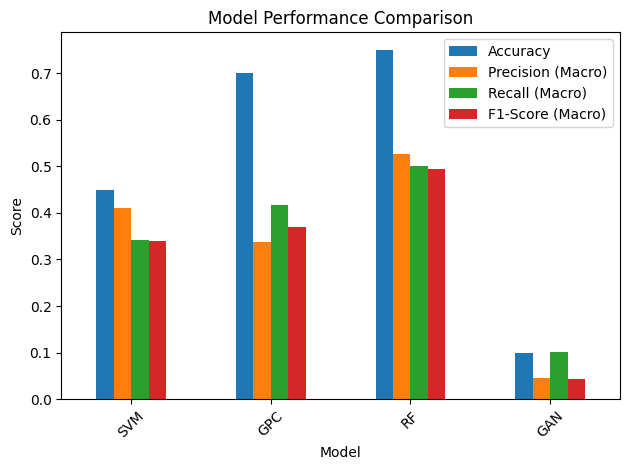

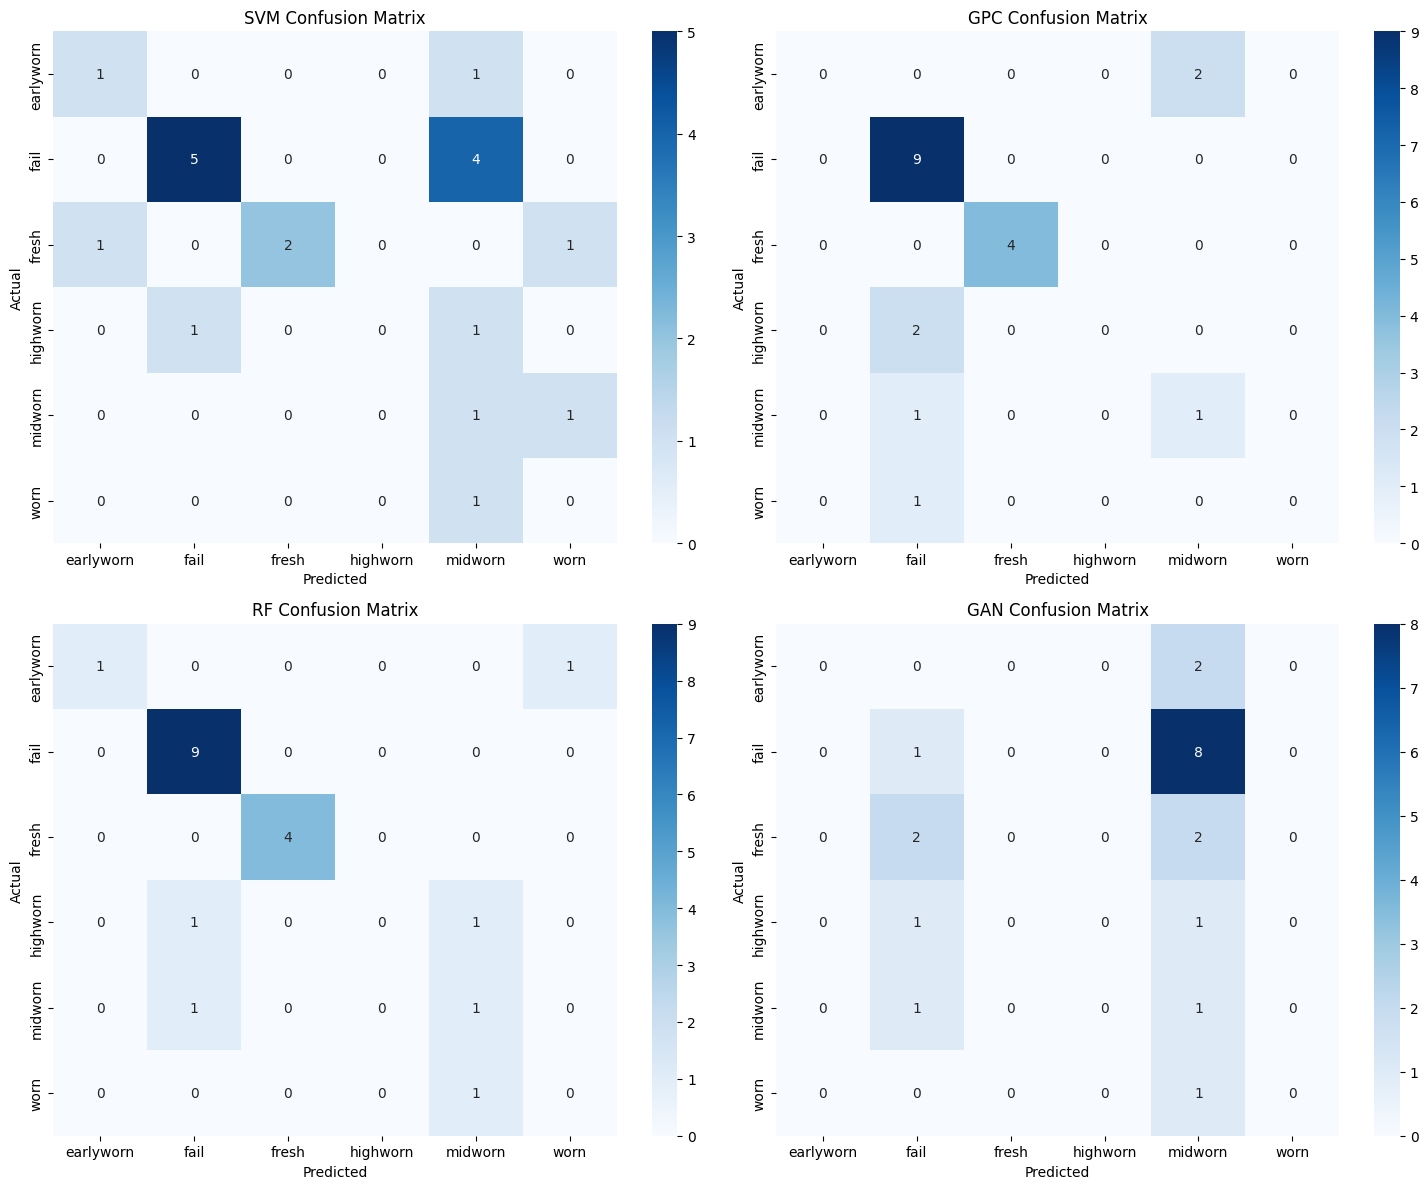

<Figure size 1000x600 with 0 Axes>

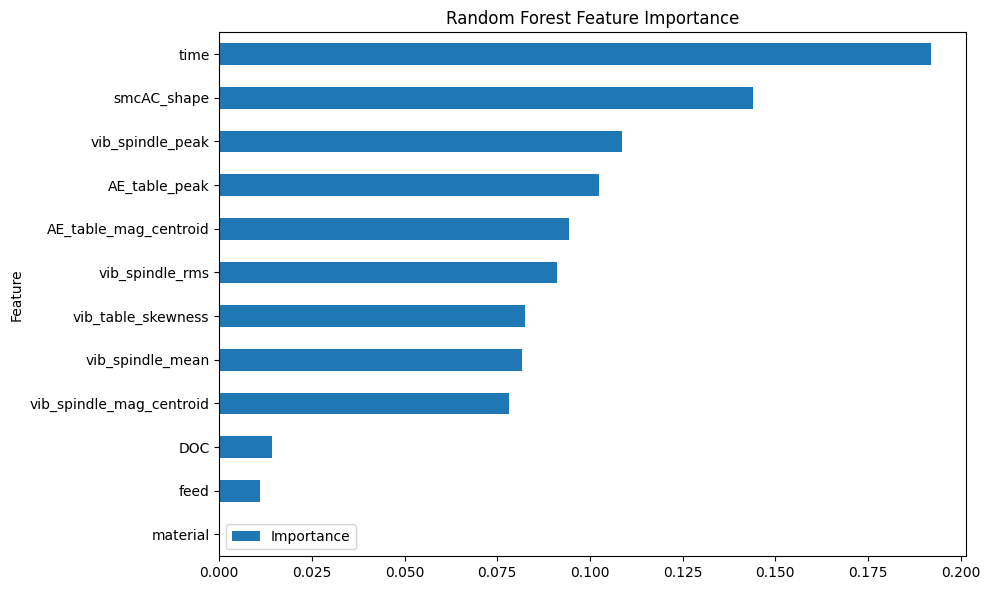


Final Model Performance:
  Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  \
0   SVM      0.45             0.4097          0.3426            0.3389   
1   GPC      0.70             0.3376          0.4167            0.3697   
2    RF      0.75             0.5253          0.5000            0.4944   
3   GAN      0.10             0.0444          0.1019            0.0434   

   ROC-AUC (Macro)  
0           0.8058  
1           0.8342  
2           0.8034  
3           0.6559  


In [ ]:
#Training all the evaluation models
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Reproducibility settings
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

class GANClassifier(Model):
    def __init__(self, num_classes, input_dim=12):
        super().__init__()
        self.num_classes = num_classes
        self.input_dim = input_dim

        # Generator
        self.generator = tf.keras.Sequential([
            layers.Dense(128, input_shape=(64,)),
            layers.LeakyReLU(0.2),
            layers.BatchNormalization(),
            layers.Dense(256),
            layers.LeakyReLU(0.2),
            layers.BatchNormalization(),
            layers.Dense(input_dim, activation='tanh')
        ])

        # Discriminator/Classifier
        self.discriminator = tf.keras.Sequential([
            layers.Dense(256, input_shape=(input_dim,)),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            layers.Dense(128),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            layers.Dense(1 + num_classes)
        ])

    def call(self, inputs):
        """Implementation of the forward pass"""
        return self.discriminator(inputs)

    def compile(self, g_optimizer, d_optimizer, loss_fn, **kwargs):
        # Add a dummy loss function to satisfy Keras requirements
        super().compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), **kwargs)
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn
        self.d_accuracy_metric = tf.keras.metrics.BinaryAccuracy()
        self.g_accuracy_metric = tf.keras.metrics.BinaryAccuracy()
        self.class_accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()

    @tf.function
    def train_step(self, data):
        x, y = data
        batch_size = tf.shape(x)[0]
        noise = tf.random.normal([batch_size, 64])

        # Train discriminator
        with tf.GradientTape() as disc_tape:
            # Real data
            d_real = self.discriminator(x)
            real_validity = d_real[:, 0]
            real_class = d_real[:, 1:]

            # Fake data
            fake_data = self.generator(noise)
            d_fake = self.discriminator(fake_data)
            fake_validity = d_fake[:, 0]

            # Discriminator losses
            d_loss_real = self.loss_fn(tf.ones_like(real_validity), real_validity)
            d_loss_fake = self.loss_fn(tf.zeros_like(fake_validity), fake_validity)
            d_loss_gan = (d_loss_real + d_loss_fake) / 2

            # Classification loss
            class_loss = tf.keras.losses.sparse_categorical_crossentropy(
                y, real_class, from_logits=True
            )

            # Total discriminator loss
            d_loss = d_loss_gan + tf.reduce_mean(class_loss)

        # Update discriminator
        d_grads = disc_tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_weights))

        # Train generator
        with tf.GradientTape() as gen_tape:
            fake_data = self.generator(noise)
            d_fake = self.discriminator(fake_data)
            fake_validity = d_fake[:, 0]
            g_loss = self.loss_fn(tf.ones_like(fake_validity), fake_validity)

        # Update generator
        g_grads = gen_tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_weights))

        # Update metrics
        self.d_accuracy_metric.update_state(tf.ones_like(real_validity), tf.sigmoid(real_validity))
        self.d_accuracy_metric.update_state(tf.zeros_like(fake_validity), tf.sigmoid(fake_validity))
        self.g_accuracy_metric.update_state(tf.ones_like(fake_validity), tf.sigmoid(fake_validity))
        self.class_accuracy_metric.update_state(y, real_class)

        return {
            "d_loss": d_loss_gan,
            "g_loss": g_loss,
            "class_loss": tf.reduce_mean(class_loss),
            "d_acc": self.d_accuracy_metric.result(),
            "g_acc": self.g_accuracy_metric.result(),
            "class_acc": self.class_accuracy_metric.result()
        }

    def predict(self, x):
        """Predict class labels"""
        d_out = self.discriminator(x)
        class_logits = d_out[:, 1:]  # Get only classification outputs
        return tf.argmax(class_logits, axis=1)

class ToolWearClassifier:
    def __init__(self):
        self.features = [
            'DOC', 'time', 'feed', 'material',
            'vib_spindle_rms', 'vib_spindle_mean', 'vib_spindle_peak',
            'AE_table_mag_centroid', 'smcAC_shape', 'vib_table_skewness',
            'vib_spindle_mag_centroid', 'AE_table_peak'
        ]
        self.le = LabelEncoder()
        self.imputer = SimpleImputer(strategy='mean')
        self.scaler = StandardScaler()
        self.models = {}
        self.results = []

    def load_data(self, synth_path, test_path):
        """Load and preprocess data"""
        self.synth_df = pd.read_csv(synth_path)
        self.test_df = pd.read_csv(test_path)

        # Encode classes
        self.synth_df['VB_class_encoded'] = self.le.fit_transform(self.synth_df['VB_class'])
        self.test_df['VB_class_encoded'] = self.le.transform(self.test_df['VB_class'])

        # Prepare features
        self.X_train = self.synth_df[self.features]
        self.y_train = self.synth_df['VB_class_encoded']
        self.X_test = self.test_df[self.features]
        self.y_test = self.test_df['VB_class_encoded']

        # Handle missing values and scale
        self.X_train = pd.DataFrame(
            self.imputer.fit_transform(self.X_train),
            columns=self.features
        )
        self.X_test = pd.DataFrame(
            self.imputer.transform(self.X_test),
            columns=self.features
        )

        self.X_train_sc = self.scaler.fit_transform(self.X_train)
        self.X_test_sc = self.scaler.transform(self.X_test)

    def evaluate_model(self, name, y_pred, y_pred_proba=None):
        """Enhanced evaluation metrics"""
        metrics = {
            'Model': name,
            'Accuracy': accuracy_score(self.y_test, y_pred),
            'Precision (Macro)': precision_score(self.y_test, y_pred, average='macro'),
            'Recall (Macro)': recall_score(self.y_test, y_pred, average='macro'),
            'F1-Score (Macro)': f1_score(self.y_test, y_pred, average='macro')
        }

        if y_pred_proba is not None:
            metrics['ROC-AUC (Macro)'] = roc_auc_score(
                tf.keras.utils.to_categorical(self.y_test),
                y_pred_proba,
                average='macro'
            )

        self.results.append(metrics)
        return metrics

    def train_svm(self):
        """Train SVM with optimized parameters"""
        print("Training SVM...")
        self.models['SVM'] = SVC(
            kernel='rbf',
            C=10,
            gamma='scale',
            probability=True,
            random_state=42
        )
        self.models['SVM'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['SVM'].predict(self.X_test_sc)
        y_pred_proba = self.models['SVM'].predict_proba(self.X_test_sc)
        return self.evaluate_model('SVM', y_pred, y_pred_proba)

    def train_gpc(self):
        """Train GPC with optimized kernel"""
        print("Training GPC...")
        kernel = C(1.0) * RBF(length_scale=1.0)
        self.models['GPC'] = GaussianProcessClassifier(
            kernel=kernel,
            random_state=42,
            n_jobs=-1
        )
        self.models['GPC'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['GPC'].predict(self.X_test_sc)
        y_pred_proba = self.models['GPC'].predict_proba(self.X_test_sc)
        return self.evaluate_model('GPC', y_pred, y_pred_proba)

    def train_rf(self):
        """Train Random Forest with optimized parameters"""
        print("Training RF...")
        self.models['RF'] = RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        self.models['RF'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['RF'].predict(self.X_test_sc)
        y_pred_proba = self.models['RF'].predict_proba(self.X_test_sc)
        return self.evaluate_model('RF', y_pred, y_pred_proba)

    def train_gan(self):
        """Train improved GAN classifier"""
        print("Training GAN...")
        num_classes = len(self.le.classes_)
        gan_clf = GANClassifier(num_classes=num_classes, input_dim=len(self.features))

        callbacks = [
            EarlyStopping(
                monitor='class_acc',
                patience=10,
                restore_best_weights=True,
                mode='max'
            ),
            ReduceLROnPlateau(
                monitor='class_acc',
                factor=0.5,
                patience=30,
                min_lr=1e-6,
                mode='max'
            )
        ]

        gan_clf.compile(
            g_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
            d_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
            loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True)
        )

        history = gan_clf.fit(
            self.X_train_sc, self.y_train,
            epochs=500,
            batch_size=32,
            callbacks=callbacks,
            validation_split=0.2,
            verbose=1
        )

        self.models['GAN'] = gan_clf
        y_pred = gan_clf.predict(self.X_test_sc)
        d_out = gan_clf.discriminator(self.X_test_sc)
        y_pred_proba = tf.nn.softmax(d_out[:, 1:]).numpy()

        return self.evaluate_model('GAN', y_pred, y_pred_proba)

    def plot_results(self):
        """Enhanced visualization of results"""
        # 1. Model Performance Comparison
        results_df = pd.DataFrame(self.results)
        plt.figure(figsize=(12, 6))
        results_df.set_index('Model')[
            ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
        ].plot(kind='bar')
        plt.title('Model Performance Comparison')
        plt.ylabel('Score')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # 2. Confusion Matrices
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        for ax, (name, model) in zip(axes.flatten(), self.models.items()):
            if name == 'GAN':
                y_pred = model.predict(self.X_test_sc)
            else:
                y_pred = model.predict(self.X_test_sc)
            cm = confusion_matrix(self.y_test, y_pred)
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=self.le.classes_,
                yticklabels=self.le.classes_
            )
            ax.set_title(f'{name} Confusion Matrix')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')
        plt.tight_layout()
        plt.show()

        # 3. Feature Importance (for RF)
        if 'RF' in self.models:
            plt.figure(figsize=(10, 6))
            importances = self.models['RF'].feature_importances_
            feature_imp = pd.DataFrame({
                'Feature': self.features,
                'Importance': importances
            }).sort_values('Importance', ascending=True)

            feature_imp.plot(
                kind='barh',
                x='Feature',
                y='Importance',
                figsize=(10, 6)
            )
            plt.title('Random Forest Feature Importance')
            plt.tight_layout()
            plt.show()

def main():
    # Initialize classifier
    classifier = ToolWearClassifier()

    try:
        # Load data
        print("Loading and preprocessing data...")
        classifier.load_data(
            '/content/drive/MyDrive/ColabNotebooks/Material2_Train_6cases.csv',
            '/content/drive/MyDrive/ColabNotebooks/Material2_Test_2cases.csv'
        )

        # Train all models
        print("\nTraining models...")
        classifier.train_svm()
        classifier.train_gpc()
        classifier.train_rf()
        classifier.train_gan()

        # Plot results
        print("\nGenerating visualizations...")
        classifier.plot_results()

        # Print final results
        results_df = pd.DataFrame(classifier.results)
        print("\nFinal Model Performance:")
        print(results_df.round(4))

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        raise

if __name__ == "__main__":
    main()

Loading and preprocessing data...

Training models...
Training SVM...
Training GPC...
Training RF...
Training GAN...
Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - class_acc: 0.1850 - class_loss: 1.7769 - d_acc: 0.4679 - d_loss: 0.6990 - g_acc: 0.8483 - g_loss: 0.6592 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9206 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - class_acc: 0.1962 - class_loss: 1.7555 - d_acc: 0.4359 - d_loss: 0.6963 - g_acc: 0.9506 - g_loss: 0.6597 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9196 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - class_acc: 0.2569 - class_loss: 1.7362 - d_acc: 0.4755 - d_loss: 0.6993 - g_acc: 0.9012 - g_loss: 0.6507 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9184 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4

<Figure size 1200x600 with 0 Axes>

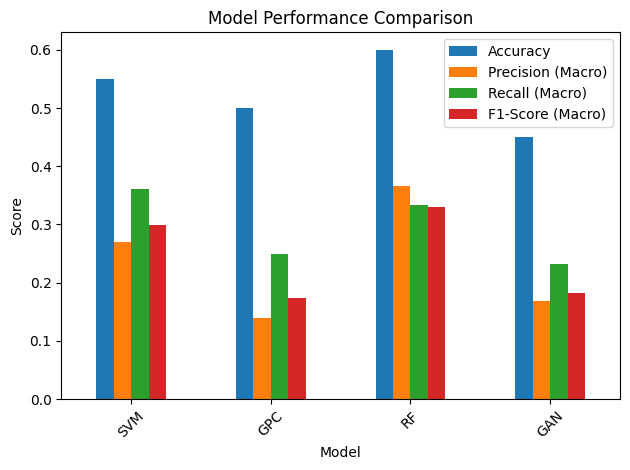

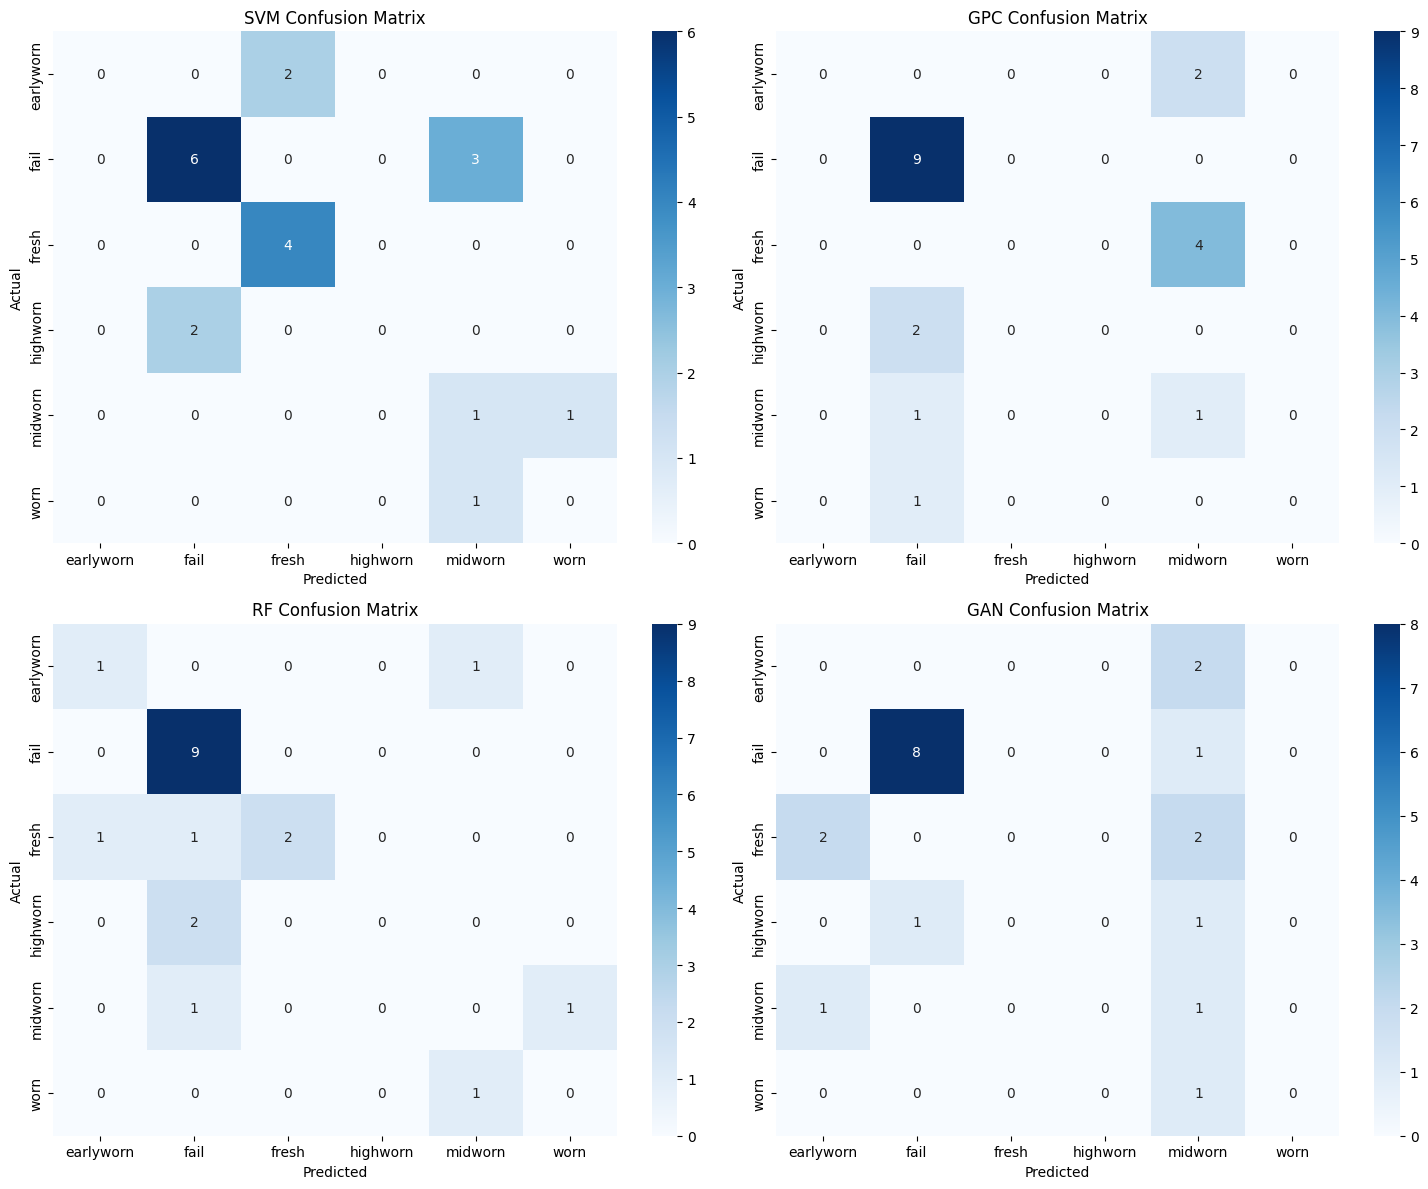

<Figure size 1000x600 with 0 Axes>

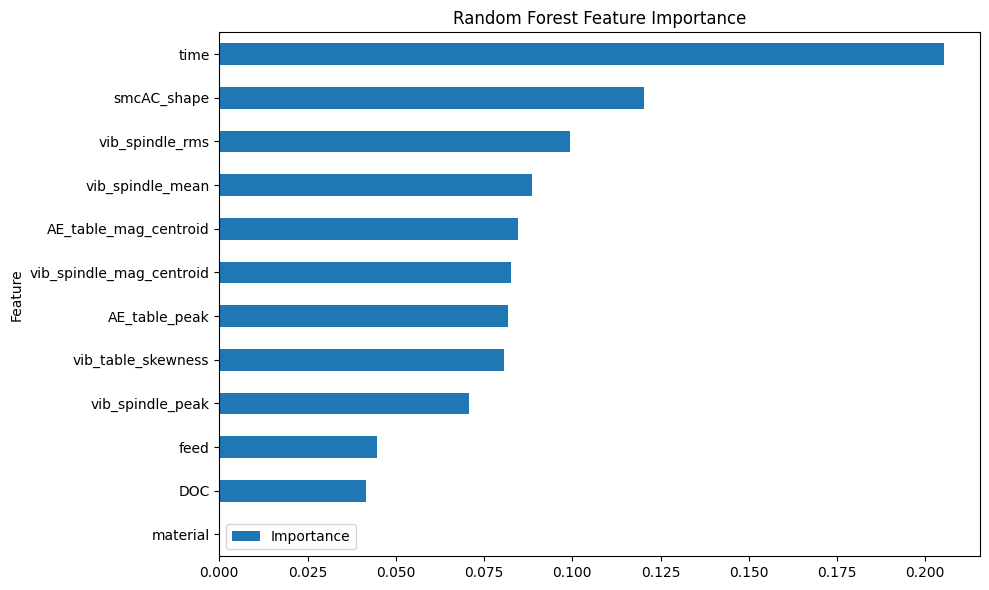


Final Model Performance:
  Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  \
0   SVM      0.55             0.2694          0.3611            0.2986   
1   GPC      0.50             0.1392          0.2500            0.1734   
2    RF      0.60             0.3654          0.3333            0.3308   
3   GAN      0.45             0.1690          0.2315            0.1815   

   ROC-AUC (Macro)  
0           0.6912  
1           0.7681  
2           0.7691  
3           0.7415  


In [ ]:
#Training all the evaluation models
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Reproducibility settings
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

class GANClassifier(Model):
    def __init__(self, num_classes, input_dim=12):
        super().__init__()
        self.num_classes = num_classes
        self.input_dim = input_dim

        # Generator
        self.generator = tf.keras.Sequential([
            layers.Dense(128, input_shape=(64,)),
            layers.LeakyReLU(0.2),
            layers.BatchNormalization(),
            layers.Dense(256),
            layers.LeakyReLU(0.2),
            layers.BatchNormalization(),
            layers.Dense(input_dim, activation='tanh')
        ])

        # Discriminator/Classifier
        self.discriminator = tf.keras.Sequential([
            layers.Dense(256, input_shape=(input_dim,)),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            layers.Dense(128),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            layers.Dense(1 + num_classes)
        ])

    def call(self, inputs):
        """Implementation of the forward pass"""
        return self.discriminator(inputs)

    def compile(self, g_optimizer, d_optimizer, loss_fn, **kwargs):
        # Add a dummy loss function to satisfy Keras requirements
        super().compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), **kwargs)
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn
        self.d_accuracy_metric = tf.keras.metrics.BinaryAccuracy()
        self.g_accuracy_metric = tf.keras.metrics.BinaryAccuracy()
        self.class_accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()

    @tf.function
    def train_step(self, data):
        x, y = data
        batch_size = tf.shape(x)[0]
        noise = tf.random.normal([batch_size, 64])

        # Train discriminator
        with tf.GradientTape() as disc_tape:
            # Real data
            d_real = self.discriminator(x)
            real_validity = d_real[:, 0]
            real_class = d_real[:, 1:]

            # Fake data
            fake_data = self.generator(noise)
            d_fake = self.discriminator(fake_data)
            fake_validity = d_fake[:, 0]

            # Discriminator losses
            d_loss_real = self.loss_fn(tf.ones_like(real_validity), real_validity)
            d_loss_fake = self.loss_fn(tf.zeros_like(fake_validity), fake_validity)
            d_loss_gan = (d_loss_real + d_loss_fake) / 2

            # Classification loss
            class_loss = tf.keras.losses.sparse_categorical_crossentropy(
                y, real_class, from_logits=True
            )

            # Total discriminator loss
            d_loss = d_loss_gan + tf.reduce_mean(class_loss)

        # Update discriminator
        d_grads = disc_tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_weights))

        # Train generator
        with tf.GradientTape() as gen_tape:
            fake_data = self.generator(noise)
            d_fake = self.discriminator(fake_data)
            fake_validity = d_fake[:, 0]
            g_loss = self.loss_fn(tf.ones_like(fake_validity), fake_validity)

        # Update generator
        g_grads = gen_tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_weights))

        # Update metrics
        self.d_accuracy_metric.update_state(tf.ones_like(real_validity), tf.sigmoid(real_validity))
        self.d_accuracy_metric.update_state(tf.zeros_like(fake_validity), tf.sigmoid(fake_validity))
        self.g_accuracy_metric.update_state(tf.ones_like(fake_validity), tf.sigmoid(fake_validity))
        self.class_accuracy_metric.update_state(y, real_class)

        return {
            "d_loss": d_loss_gan,
            "g_loss": g_loss,
            "class_loss": tf.reduce_mean(class_loss),
            "d_acc": self.d_accuracy_metric.result(),
            "g_acc": self.g_accuracy_metric.result(),
            "class_acc": self.class_accuracy_metric.result()
        }

    def predict(self, x):
        """Predict class labels"""
        d_out = self.discriminator(x)
        class_logits = d_out[:, 1:]  # Get only classification outputs
        return tf.argmax(class_logits, axis=1)

class ToolWearClassifier:
    def __init__(self):
        self.features = [
            'DOC', 'time', 'feed', 'material',
            'vib_spindle_rms', 'vib_spindle_mean', 'vib_spindle_peak',
            'AE_table_mag_centroid', 'smcAC_shape', 'vib_table_skewness',
            'vib_spindle_mag_centroid', 'AE_table_peak'
        ]
        self.le = LabelEncoder()
        self.imputer = SimpleImputer(strategy='mean')
        self.scaler = StandardScaler()
        self.models = {}
        self.results = []

    def load_data(self, synth_path, test_path):
        """Load and preprocess data"""
        self.synth_df = pd.read_csv(synth_path)
        self.test_df = pd.read_csv(test_path)

        # Encode classes
        self.synth_df['VB_class_encoded'] = self.le.fit_transform(self.synth_df['VB_class'])
        self.test_df['VB_class_encoded'] = self.le.transform(self.test_df['VB_class'])

        # Prepare features
        self.X_train = self.synth_df[self.features]
        self.y_train = self.synth_df['VB_class_encoded']
        self.X_test = self.test_df[self.features]
        self.y_test = self.test_df['VB_class_encoded']

        # Handle missing values and scale
        self.X_train = pd.DataFrame(
            self.imputer.fit_transform(self.X_train),
            columns=self.features
        )
        self.X_test = pd.DataFrame(
            self.imputer.transform(self.X_test),
            columns=self.features
        )

        self.X_train_sc = self.scaler.fit_transform(self.X_train)
        self.X_test_sc = self.scaler.transform(self.X_test)

    def evaluate_model(self, name, y_pred, y_pred_proba=None):
        """Enhanced evaluation metrics"""
        metrics = {
            'Model': name,
            'Accuracy': accuracy_score(self.y_test, y_pred),
            'Precision (Macro)': precision_score(self.y_test, y_pred, average='macro'),
            'Recall (Macro)': recall_score(self.y_test, y_pred, average='macro'),
            'F1-Score (Macro)': f1_score(self.y_test, y_pred, average='macro')
        }

        if y_pred_proba is not None:
            metrics['ROC-AUC (Macro)'] = roc_auc_score(
                tf.keras.utils.to_categorical(self.y_test),
                y_pred_proba,
                average='macro'
            )

        self.results.append(metrics)
        return metrics

    def train_svm(self):
        """Train SVM with optimized parameters"""
        print("Training SVM...")
        self.models['SVM'] = SVC(
            kernel='rbf',
            C=10,
            gamma='scale',
            probability=True,
            random_state=42
        )
        self.models['SVM'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['SVM'].predict(self.X_test_sc)
        y_pred_proba = self.models['SVM'].predict_proba(self.X_test_sc)
        return self.evaluate_model('SVM', y_pred, y_pred_proba)

    def train_gpc(self):
        """Train GPC with optimized kernel"""
        print("Training GPC...")
        kernel = C(1.0) * RBF(length_scale=1.0)
        self.models['GPC'] = GaussianProcessClassifier(
            kernel=kernel,
            random_state=42,
            n_jobs=-1
        )
        self.models['GPC'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['GPC'].predict(self.X_test_sc)
        y_pred_proba = self.models['GPC'].predict_proba(self.X_test_sc)
        return self.evaluate_model('GPC', y_pred, y_pred_proba)

    def train_rf(self):
        """Train Random Forest with optimized parameters"""
        print("Training RF...")
        self.models['RF'] = RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        self.models['RF'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['RF'].predict(self.X_test_sc)
        y_pred_proba = self.models['RF'].predict_proba(self.X_test_sc)
        return self.evaluate_model('RF', y_pred, y_pred_proba)

    def train_gan(self):
        """Train improved GAN classifier"""
        print("Training GAN...")
        num_classes = len(self.le.classes_)
        gan_clf = GANClassifier(num_classes=num_classes, input_dim=len(self.features))

        callbacks = [
            EarlyStopping(
                monitor='class_acc',
                patience=10,
                restore_best_weights=True,
                mode='max'
            ),
            ReduceLROnPlateau(
                monitor='class_acc',
                factor=0.5,
                patience=30,
                min_lr=1e-6,
                mode='max'
            )
        ]

        gan_clf.compile(
            g_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
            d_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
            loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True)
        )

        history = gan_clf.fit(
            self.X_train_sc, self.y_train,
            epochs=500,
            batch_size=32,
            callbacks=callbacks,
            validation_split=0.2,
            verbose=1
        )

        self.models['GAN'] = gan_clf
        y_pred = gan_clf.predict(self.X_test_sc)
        d_out = gan_clf.discriminator(self.X_test_sc)
        y_pred_proba = tf.nn.softmax(d_out[:, 1:]).numpy()

        return self.evaluate_model('GAN', y_pred, y_pred_proba)

    def plot_results(self):
        """Enhanced visualization of results"""
        # 1. Model Performance Comparison
        results_df = pd.DataFrame(self.results)
        plt.figure(figsize=(12, 6))
        results_df.set_index('Model')[
            ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
        ].plot(kind='bar')
        plt.title('Model Performance Comparison')
        plt.ylabel('Score')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # 2. Confusion Matrices
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        for ax, (name, model) in zip(axes.flatten(), self.models.items()):
            if name == 'GAN':
                y_pred = model.predict(self.X_test_sc)
            else:
                y_pred = model.predict(self.X_test_sc)
            cm = confusion_matrix(self.y_test, y_pred)
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=self.le.classes_,
                yticklabels=self.le.classes_
            )
            ax.set_title(f'{name} Confusion Matrix')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')
        plt.tight_layout()
        plt.show()

        # 3. Feature Importance (for RF)
        if 'RF' in self.models:
            plt.figure(figsize=(10, 6))
            importances = self.models['RF'].feature_importances_
            feature_imp = pd.DataFrame({
                'Feature': self.features,
                'Importance': importances
            }).sort_values('Importance', ascending=True)

            feature_imp.plot(
                kind='barh',
                x='Feature',
                y='Importance',
                figsize=(10, 6)
            )
            plt.title('Random Forest Feature Importance')
            plt.tight_layout()
            plt.show()

def main():
    # Initialize classifier
    classifier = ToolWearClassifier()

    try:
        # Load data
        print("Loading and preprocessing data...")
        classifier.load_data(
            '/content/drive/MyDrive/ColabNotebooks/combined_real_synthetic_data_mat2_10.csv',
            '/content/drive/MyDrive/ColabNotebooks/Material2_Test_2cases.csv'
        )

        # Train all models
        print("\nTraining models...")
        classifier.train_svm()
        classifier.train_gpc()
        classifier.train_rf()
        classifier.train_gan()

        # Plot results
        print("\nGenerating visualizations...")
        classifier.plot_results()

        # Print final results
        results_df = pd.DataFrame(classifier.results)
        print("\nFinal Model Performance:")
        print(results_df.round(4))

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        raise

if __name__ == "__main__":
    main()

Loading and preprocessing data...

Training models...
Training SVM...
Training GPC...
Training RF...
Training GAN...
Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 235ms/step - class_acc: 0.1663 - class_loss: 1.8299 - d_acc: 0.4264 - d_loss: 0.6998 - g_acc: 0.8601 - g_loss: 0.6581 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.8904 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - class_acc: 0.1758 - class_loss: 1.8101 - d_acc: 0.4283 - d_loss: 0.6988 - g_acc: 0.9082 - g_loss: 0.6530 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.8936 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - class_acc: 0.2027 - class_loss: 1.7917 - d_acc: 0.4437 - d_loss: 0.6956 - g_acc: 0.9043 - g_loss: 0.6524 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.8972 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72

<Figure size 1200x600 with 0 Axes>

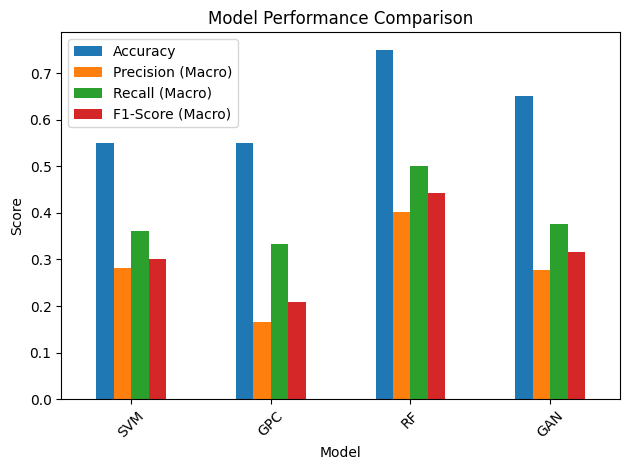

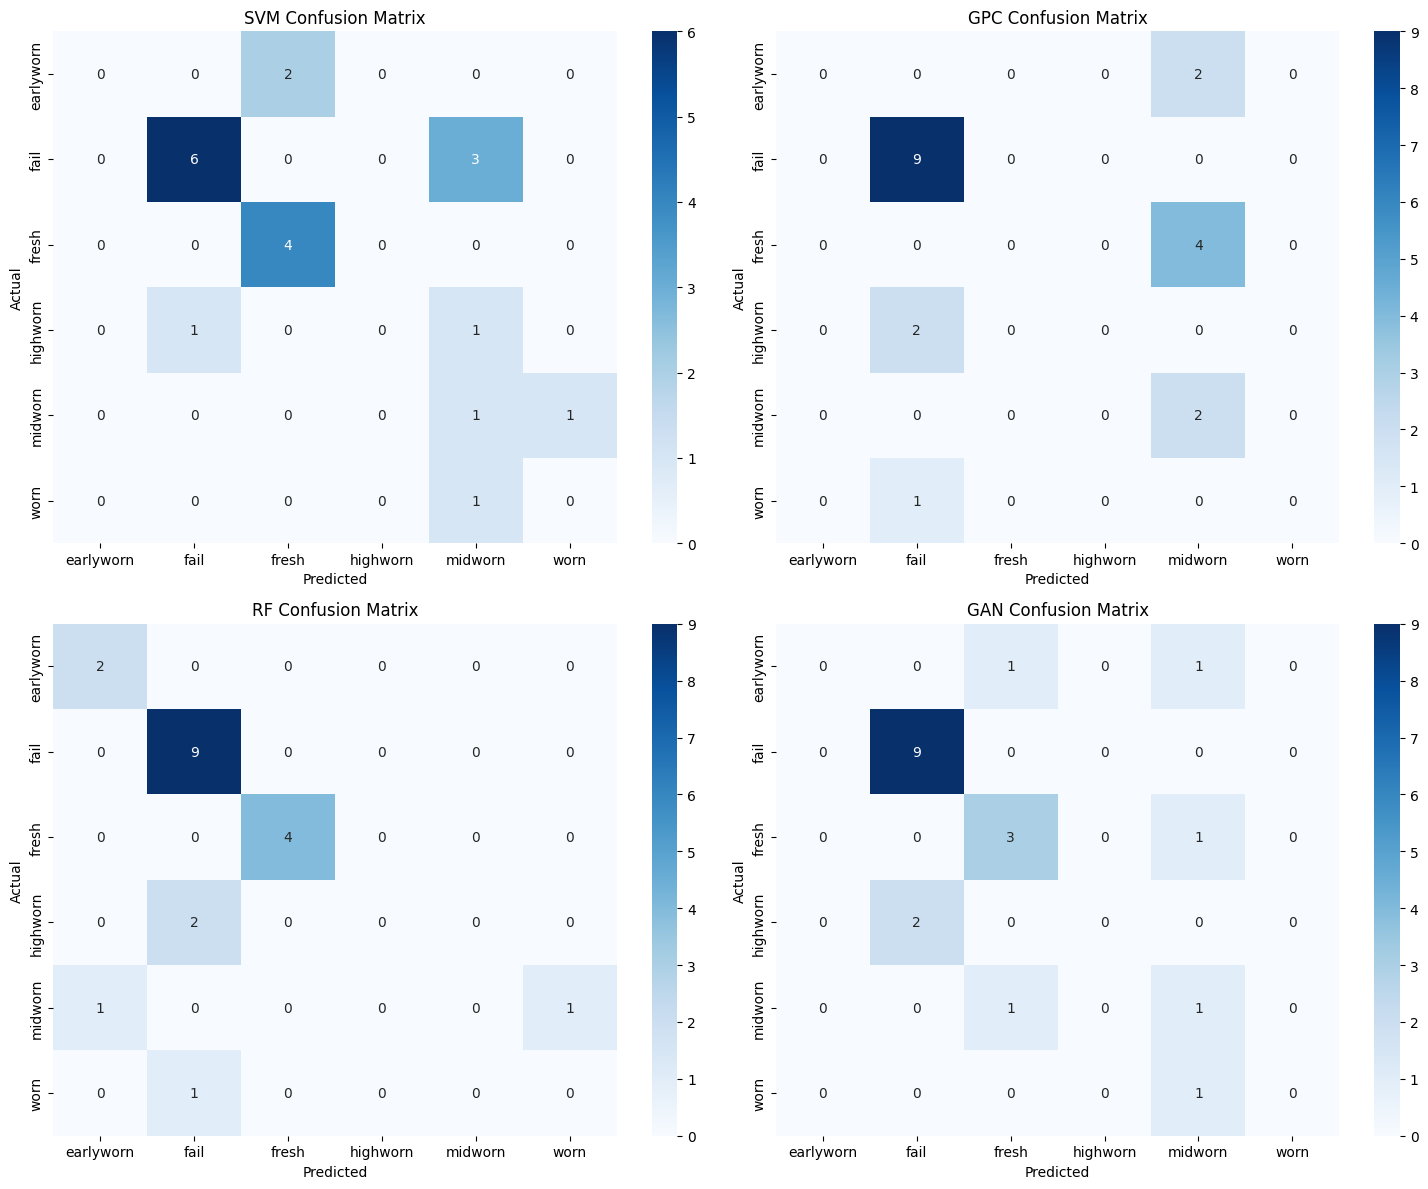

<Figure size 1000x600 with 0 Axes>

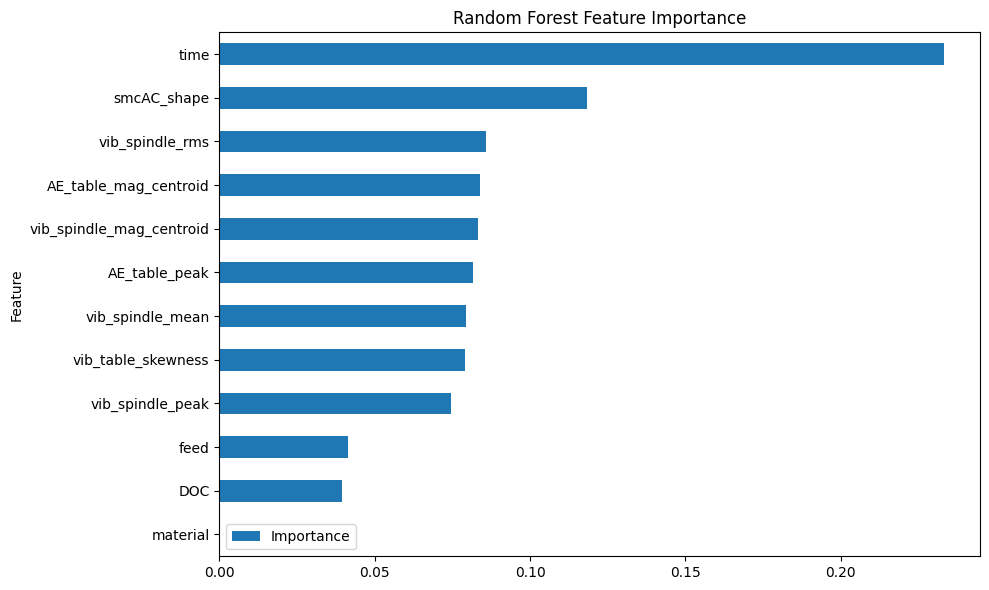


Final Model Performance:
  Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  \
0   SVM      0.55             0.2817          0.3611            0.3000   
1   GPC      0.55             0.1667          0.3333            0.2095   
2    RF      0.75             0.4028          0.5000            0.4429   
3   GAN      0.65             0.2780          0.3750            0.3167   

   ROC-AUC (Macro)  
0           0.7734  
1           0.7661  
2           0.8521  
3           0.9232  


In [ ]:
#Training all the evaluation models
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Reproducibility settings
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

class GANClassifier(Model):
    def __init__(self, num_classes, input_dim=12):
        super().__init__()
        self.num_classes = num_classes
        self.input_dim = input_dim

        # Generator
        self.generator = tf.keras.Sequential([
            layers.Dense(128, input_shape=(64,)),
            layers.LeakyReLU(0.2),
            layers.BatchNormalization(),
            layers.Dense(256),
            layers.LeakyReLU(0.2),
            layers.BatchNormalization(),
            layers.Dense(input_dim, activation='tanh')
        ])

        # Discriminator/Classifier
        self.discriminator = tf.keras.Sequential([
            layers.Dense(256, input_shape=(input_dim,)),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            layers.Dense(128),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            layers.Dense(1 + num_classes)
        ])

    def call(self, inputs):
        """Implementation of the forward pass"""
        return self.discriminator(inputs)

    def compile(self, g_optimizer, d_optimizer, loss_fn, **kwargs):
        # Add a dummy loss function to satisfy Keras requirements
        super().compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), **kwargs)
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn
        self.d_accuracy_metric = tf.keras.metrics.BinaryAccuracy()
        self.g_accuracy_metric = tf.keras.metrics.BinaryAccuracy()
        self.class_accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()

    @tf.function
    def train_step(self, data):
        x, y = data
        batch_size = tf.shape(x)[0]
        noise = tf.random.normal([batch_size, 64])

        # Train discriminator
        with tf.GradientTape() as disc_tape:
            # Real data
            d_real = self.discriminator(x)
            real_validity = d_real[:, 0]
            real_class = d_real[:, 1:]

            # Fake data
            fake_data = self.generator(noise)
            d_fake = self.discriminator(fake_data)
            fake_validity = d_fake[:, 0]

            # Discriminator losses
            d_loss_real = self.loss_fn(tf.ones_like(real_validity), real_validity)
            d_loss_fake = self.loss_fn(tf.zeros_like(fake_validity), fake_validity)
            d_loss_gan = (d_loss_real + d_loss_fake) / 2

            # Classification loss
            class_loss = tf.keras.losses.sparse_categorical_crossentropy(
                y, real_class, from_logits=True
            )

            # Total discriminator loss
            d_loss = d_loss_gan + tf.reduce_mean(class_loss)

        # Update discriminator
        d_grads = disc_tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_weights))

        # Train generator
        with tf.GradientTape() as gen_tape:
            fake_data = self.generator(noise)
            d_fake = self.discriminator(fake_data)
            fake_validity = d_fake[:, 0]
            g_loss = self.loss_fn(tf.ones_like(fake_validity), fake_validity)

        # Update generator
        g_grads = gen_tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_weights))

        # Update metrics
        self.d_accuracy_metric.update_state(tf.ones_like(real_validity), tf.sigmoid(real_validity))
        self.d_accuracy_metric.update_state(tf.zeros_like(fake_validity), tf.sigmoid(fake_validity))
        self.g_accuracy_metric.update_state(tf.ones_like(fake_validity), tf.sigmoid(fake_validity))
        self.class_accuracy_metric.update_state(y, real_class)

        return {
            "d_loss": d_loss_gan,
            "g_loss": g_loss,
            "class_loss": tf.reduce_mean(class_loss),
            "d_acc": self.d_accuracy_metric.result(),
            "g_acc": self.g_accuracy_metric.result(),
            "class_acc": self.class_accuracy_metric.result()
        }

    def predict(self, x):
        """Predict class labels"""
        d_out = self.discriminator(x)
        class_logits = d_out[:, 1:]  # Get only classification outputs
        return tf.argmax(class_logits, axis=1)

class ToolWearClassifier:
    def __init__(self):
        self.features = [
            'DOC', 'time', 'feed', 'material',
            'vib_spindle_rms', 'vib_spindle_mean', 'vib_spindle_peak',
            'AE_table_mag_centroid', 'smcAC_shape', 'vib_table_skewness',
            'vib_spindle_mag_centroid', 'AE_table_peak'
        ]
        self.le = LabelEncoder()
        self.imputer = SimpleImputer(strategy='mean')
        self.scaler = StandardScaler()
        self.models = {}
        self.results = []

    def load_data(self, synth_path, test_path):
        """Load and preprocess data"""
        self.synth_df = pd.read_csv(synth_path)
        self.test_df = pd.read_csv(test_path)

        # Encode classes
        self.synth_df['VB_class_encoded'] = self.le.fit_transform(self.synth_df['VB_class'])
        self.test_df['VB_class_encoded'] = self.le.transform(self.test_df['VB_class'])

        # Prepare features
        self.X_train = self.synth_df[self.features]
        self.y_train = self.synth_df['VB_class_encoded']
        self.X_test = self.test_df[self.features]
        self.y_test = self.test_df['VB_class_encoded']

        # Handle missing values and scale
        self.X_train = pd.DataFrame(
            self.imputer.fit_transform(self.X_train),
            columns=self.features
        )
        self.X_test = pd.DataFrame(
            self.imputer.transform(self.X_test),
            columns=self.features
        )

        self.X_train_sc = self.scaler.fit_transform(self.X_train)
        self.X_test_sc = self.scaler.transform(self.X_test)

    def evaluate_model(self, name, y_pred, y_pred_proba=None):
        """Enhanced evaluation metrics"""
        metrics = {
            'Model': name,
            'Accuracy': accuracy_score(self.y_test, y_pred),
            'Precision (Macro)': precision_score(self.y_test, y_pred, average='macro'),
            'Recall (Macro)': recall_score(self.y_test, y_pred, average='macro'),
            'F1-Score (Macro)': f1_score(self.y_test, y_pred, average='macro')
        }

        if y_pred_proba is not None:
            metrics['ROC-AUC (Macro)'] = roc_auc_score(
                tf.keras.utils.to_categorical(self.y_test),
                y_pred_proba,
                average='macro'
            )

        self.results.append(metrics)
        return metrics

    def train_svm(self):
        """Train SVM with optimized parameters"""
        print("Training SVM...")
        self.models['SVM'] = SVC(
            kernel='rbf',
            C=10,
            gamma='scale',
            probability=True,
            random_state=42
        )
        self.models['SVM'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['SVM'].predict(self.X_test_sc)
        y_pred_proba = self.models['SVM'].predict_proba(self.X_test_sc)
        return self.evaluate_model('SVM', y_pred, y_pred_proba)

    def train_gpc(self):
        """Train GPC with optimized kernel"""
        print("Training GPC...")
        kernel = C(1.0) * RBF(length_scale=1.0)
        self.models['GPC'] = GaussianProcessClassifier(
            kernel=kernel,
            random_state=42,
            n_jobs=-1
        )
        self.models['GPC'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['GPC'].predict(self.X_test_sc)
        y_pred_proba = self.models['GPC'].predict_proba(self.X_test_sc)
        return self.evaluate_model('GPC', y_pred, y_pred_proba)

    def train_rf(self):
        """Train Random Forest with optimized parameters"""
        print("Training RF...")
        self.models['RF'] = RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        self.models['RF'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['RF'].predict(self.X_test_sc)
        y_pred_proba = self.models['RF'].predict_proba(self.X_test_sc)
        return self.evaluate_model('RF', y_pred, y_pred_proba)

    def train_gan(self):
        """Train improved GAN classifier"""
        print("Training GAN...")
        num_classes = len(self.le.classes_)
        gan_clf = GANClassifier(num_classes=num_classes, input_dim=len(self.features))

        callbacks = [
            EarlyStopping(
                monitor='class_acc',
                patience=30,
                restore_best_weights=True,
                mode='max'
            ),
            ReduceLROnPlateau(
                monitor='class_acc',
                factor=0.5,
                patience=10,
                min_lr=1e-6,
                mode='max'
            )
        ]

        gan_clf.compile(
            g_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
            d_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
            loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True)
        )

        history = gan_clf.fit(
            self.X_train_sc, self.y_train,
            epochs=500,
            batch_size=32,
            callbacks=callbacks,
            validation_split=0.2,
            verbose=1
        )

        self.models['GAN'] = gan_clf
        y_pred = gan_clf.predict(self.X_test_sc)
        d_out = gan_clf.discriminator(self.X_test_sc)
        y_pred_proba = tf.nn.softmax(d_out[:, 1:]).numpy()

        return self.evaluate_model('GAN', y_pred, y_pred_proba)

    def plot_results(self):
        """Enhanced visualization of results"""
        # 1. Model Performance Comparison
        results_df = pd.DataFrame(self.results)
        plt.figure(figsize=(12, 6))
        results_df.set_index('Model')[
            ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
        ].plot(kind='bar')
        plt.title('Model Performance Comparison')
        plt.ylabel('Score')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # 2. Confusion Matrices
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        for ax, (name, model) in zip(axes.flatten(), self.models.items()):
            if name == 'GAN':
                y_pred = model.predict(self.X_test_sc)
            else:
                y_pred = model.predict(self.X_test_sc)
            cm = confusion_matrix(self.y_test, y_pred)
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=self.le.classes_,
                yticklabels=self.le.classes_
            )
            ax.set_title(f'{name} Confusion Matrix')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')
        plt.tight_layout()
        plt.show()

        # 3. Feature Importance (for RF)
        if 'RF' in self.models:
            plt.figure(figsize=(10, 6))
            importances = self.models['RF'].feature_importances_
            feature_imp = pd.DataFrame({
                'Feature': self.features,
                'Importance': importances
            }).sort_values('Importance', ascending=True)

            feature_imp.plot(
                kind='barh',
                x='Feature',
                y='Importance',
                figsize=(10, 6)
            )
            plt.title('Random Forest Feature Importance')
            plt.tight_layout()
            plt.show()

def main():
    # Initialize classifier
    classifier = ToolWearClassifier()

    try:
        # Load data
        print("Loading and preprocessing data...")
        classifier.load_data(
            '/content/drive/MyDrive/ColabNotebooks/combined_real_synthetic_data_mat2_15.csv',
            '/content/drive/MyDrive/ColabNotebooks/Material2_Test_2cases.csv'
        )

        # Train all models
        print("\nTraining models...")
        classifier.train_svm()
        classifier.train_gpc()
        classifier.train_rf()
        classifier.train_gan()

        # Plot results
        print("\nGenerating visualizations...")
        classifier.plot_results()

        # Print final results
        results_df = pd.DataFrame(classifier.results)
        print("\nFinal Model Performance:")
        print(results_df.round(4))

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        raise

if __name__ == "__main__":
    main()

Loading and preprocessing data...

Training models...
Training SVM...
Training GPC...
Training RF...
Training GAN...
Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - class_acc: 0.1484 - class_loss: 1.8196 - d_acc: 0.4208 - d_loss: 0.7002 - g_acc: 0.8533 - g_loss: 0.6566 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9039 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - class_acc: 0.2068 - class_loss: 1.7898 - d_acc: 0.4192 - d_loss: 0.7007 - g_acc: 0.9518 - g_loss: 0.6442 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9099 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - class_acc: 0.2234 - class_loss: 1.7631 - d_acc: 0.4291 - d_loss: 0.6958 - g_acc: 0.9658 - g_loss: 0.6421 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9160 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33

<Figure size 1200x600 with 0 Axes>

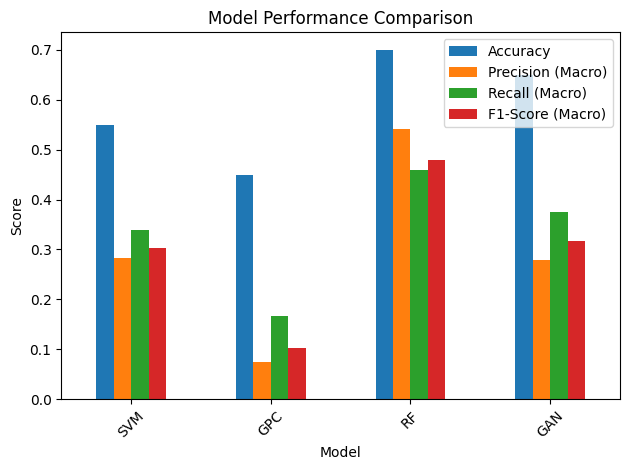

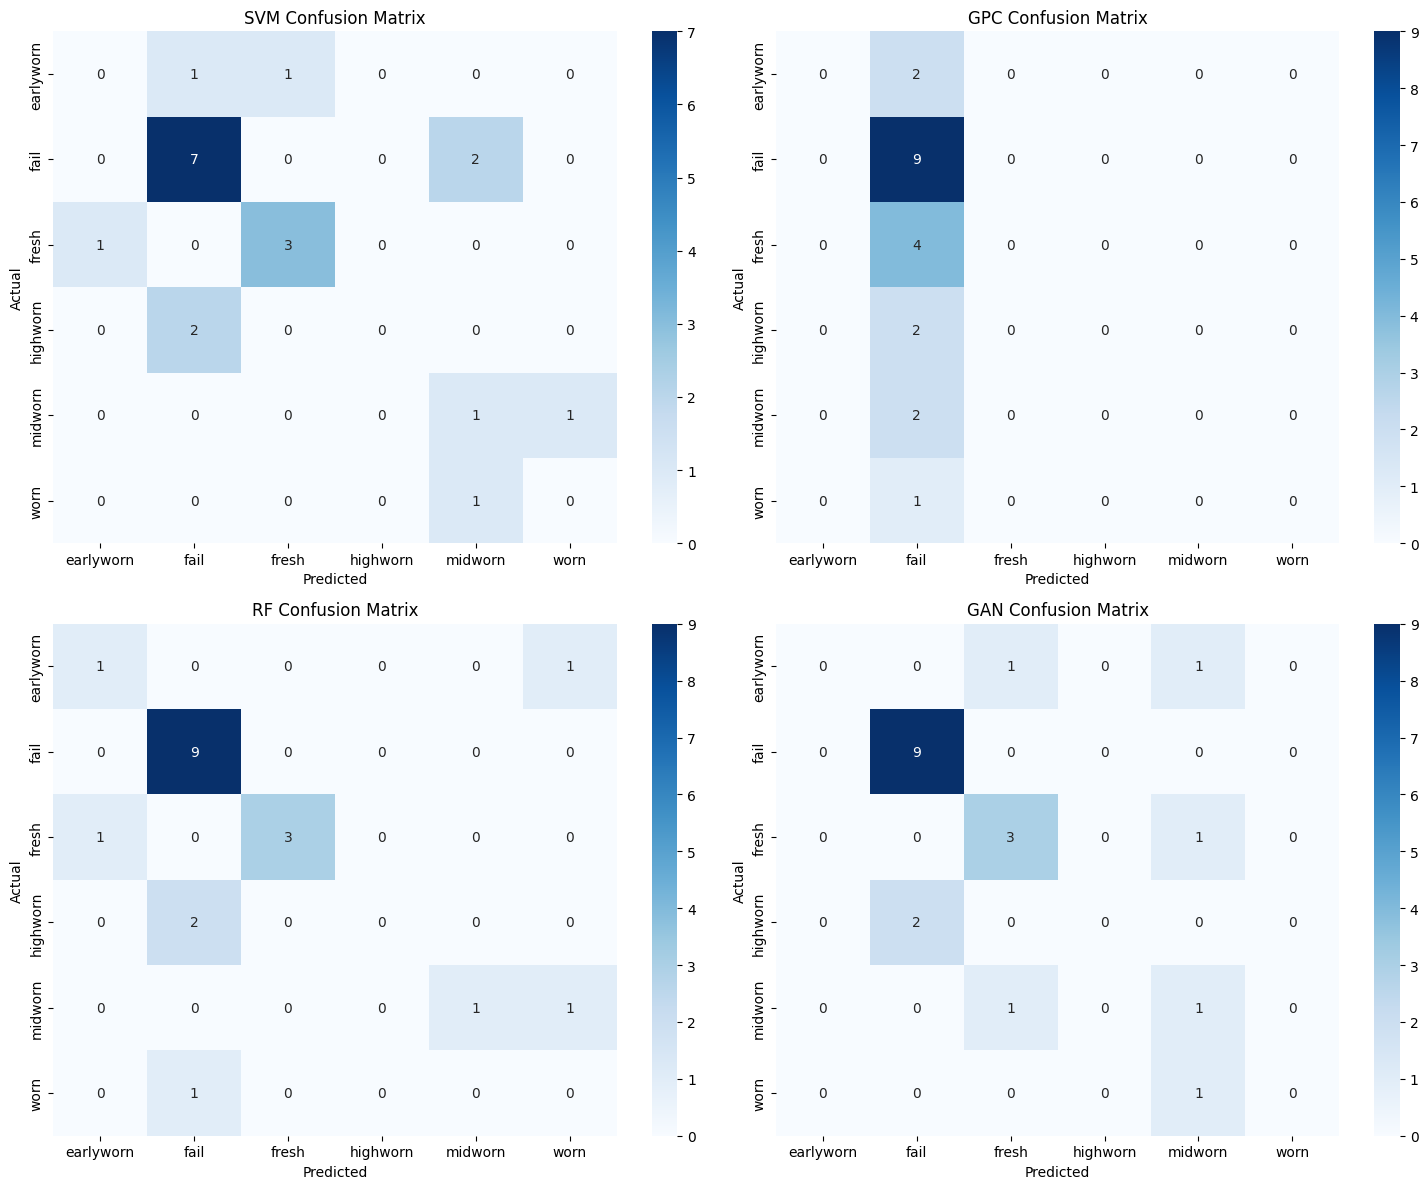

<Figure size 1000x600 with 0 Axes>

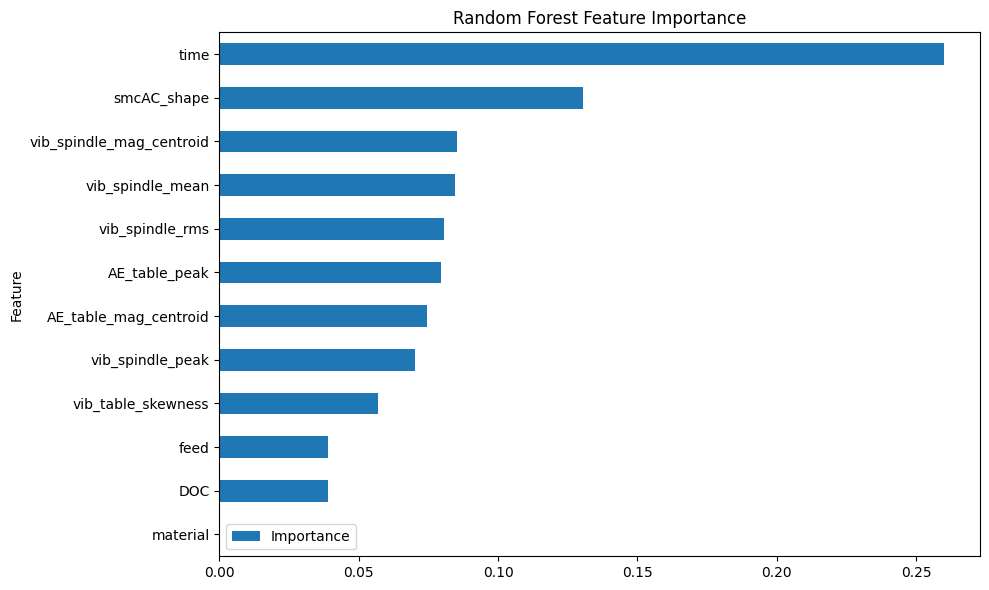


Final Model Performance:
  Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  \
0   SVM      0.55             0.2833          0.3380            0.3034   
1   GPC      0.45             0.0750          0.1667            0.1034   
2    RF      0.70             0.5417          0.4583            0.4802   
3   GAN      0.65             0.2780          0.3750            0.3167   

   ROC-AUC (Macro)  
0           0.8212  
1           0.6049  
2           0.8057  
3           0.8990  


In [ ]:
#Training all the evaluation models
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Reproducibility settings
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

class GANClassifier(Model):
    def __init__(self, num_classes, input_dim=12):
        super().__init__()
        self.num_classes = num_classes
        self.input_dim = input_dim

        # Generator
        self.generator = tf.keras.Sequential([
            layers.Dense(128, input_shape=(64,)),
            layers.LeakyReLU(0.2),
            layers.BatchNormalization(),
            layers.Dense(256),
            layers.LeakyReLU(0.2),
            layers.BatchNormalization(),
            layers.Dense(input_dim, activation='tanh')
        ])

        # Discriminator/Classifier
        self.discriminator = tf.keras.Sequential([
            layers.Dense(256, input_shape=(input_dim,)),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            layers.Dense(128),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            layers.Dense(1 + num_classes)
        ])

    def call(self, inputs):
        """Implementation of the forward pass"""
        return self.discriminator(inputs)

    def compile(self, g_optimizer, d_optimizer, loss_fn, **kwargs):
        # Add a dummy loss function to satisfy Keras requirements
        super().compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), **kwargs)
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn
        self.d_accuracy_metric = tf.keras.metrics.BinaryAccuracy()
        self.g_accuracy_metric = tf.keras.metrics.BinaryAccuracy()
        self.class_accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()

    @tf.function
    def train_step(self, data):
        x, y = data
        batch_size = tf.shape(x)[0]
        noise = tf.random.normal([batch_size, 64])

        # Train discriminator
        with tf.GradientTape() as disc_tape:
            # Real data
            d_real = self.discriminator(x)
            real_validity = d_real[:, 0]
            real_class = d_real[:, 1:]

            # Fake data
            fake_data = self.generator(noise)
            d_fake = self.discriminator(fake_data)
            fake_validity = d_fake[:, 0]

            # Discriminator losses
            d_loss_real = self.loss_fn(tf.ones_like(real_validity), real_validity)
            d_loss_fake = self.loss_fn(tf.zeros_like(fake_validity), fake_validity)
            d_loss_gan = (d_loss_real + d_loss_fake) / 2

            # Classification loss
            class_loss = tf.keras.losses.sparse_categorical_crossentropy(
                y, real_class, from_logits=True
            )

            # Total discriminator loss
            d_loss = d_loss_gan + tf.reduce_mean(class_loss)

        # Update discriminator
        d_grads = disc_tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_weights))

        # Train generator
        with tf.GradientTape() as gen_tape:
            fake_data = self.generator(noise)
            d_fake = self.discriminator(fake_data)
            fake_validity = d_fake[:, 0]
            g_loss = self.loss_fn(tf.ones_like(fake_validity), fake_validity)

        # Update generator
        g_grads = gen_tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_weights))

        # Update metrics
        self.d_accuracy_metric.update_state(tf.ones_like(real_validity), tf.sigmoid(real_validity))
        self.d_accuracy_metric.update_state(tf.zeros_like(fake_validity), tf.sigmoid(fake_validity))
        self.g_accuracy_metric.update_state(tf.ones_like(fake_validity), tf.sigmoid(fake_validity))
        self.class_accuracy_metric.update_state(y, real_class)

        return {
            "d_loss": d_loss_gan,
            "g_loss": g_loss,
            "class_loss": tf.reduce_mean(class_loss),
            "d_acc": self.d_accuracy_metric.result(),
            "g_acc": self.g_accuracy_metric.result(),
            "class_acc": self.class_accuracy_metric.result()
        }

    def predict(self, x):
        """Predict class labels"""
        d_out = self.discriminator(x)
        class_logits = d_out[:, 1:]  # Get only classification outputs
        return tf.argmax(class_logits, axis=1)

class ToolWearClassifier:
    def __init__(self):
        self.features = [
            'DOC', 'time', 'feed', 'material',
            'vib_spindle_rms', 'vib_spindle_mean', 'vib_spindle_peak',
            'AE_table_mag_centroid', 'smcAC_shape', 'vib_table_skewness',
            'vib_spindle_mag_centroid', 'AE_table_peak'
        ]
        self.le = LabelEncoder()
        self.imputer = SimpleImputer(strategy='mean')
        self.scaler = StandardScaler()
        self.models = {}
        self.results = []

    def load_data(self, synth_path, test_path):
        """Load and preprocess data"""
        self.synth_df = pd.read_csv(synth_path)
        self.test_df = pd.read_csv(test_path)

        # Encode classes
        self.synth_df['VB_class_encoded'] = self.le.fit_transform(self.synth_df['VB_class'])
        self.test_df['VB_class_encoded'] = self.le.transform(self.test_df['VB_class'])

        # Prepare features
        self.X_train = self.synth_df[self.features]
        self.y_train = self.synth_df['VB_class_encoded']
        self.X_test = self.test_df[self.features]
        self.y_test = self.test_df['VB_class_encoded']

        # Handle missing values and scale
        self.X_train = pd.DataFrame(
            self.imputer.fit_transform(self.X_train),
            columns=self.features
        )
        self.X_test = pd.DataFrame(
            self.imputer.transform(self.X_test),
            columns=self.features
        )

        self.X_train_sc = self.scaler.fit_transform(self.X_train)
        self.X_test_sc = self.scaler.transform(self.X_test)

    def evaluate_model(self, name, y_pred, y_pred_proba=None):
        """Enhanced evaluation metrics"""
        metrics = {
            'Model': name,
            'Accuracy': accuracy_score(self.y_test, y_pred),
            'Precision (Macro)': precision_score(self.y_test, y_pred, average='macro'),
            'Recall (Macro)': recall_score(self.y_test, y_pred, average='macro'),
            'F1-Score (Macro)': f1_score(self.y_test, y_pred, average='macro')
        }

        if y_pred_proba is not None:
            metrics['ROC-AUC (Macro)'] = roc_auc_score(
                tf.keras.utils.to_categorical(self.y_test),
                y_pred_proba,
                average='macro'
            )

        self.results.append(metrics)
        return metrics

    def train_svm(self):
        """Train SVM with optimized parameters"""
        print("Training SVM...")
        self.models['SVM'] = SVC(
            kernel='rbf',
            C=10,
            gamma='scale',
            probability=True,
            random_state=42
        )
        self.models['SVM'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['SVM'].predict(self.X_test_sc)
        y_pred_proba = self.models['SVM'].predict_proba(self.X_test_sc)
        return self.evaluate_model('SVM', y_pred, y_pred_proba)

    def train_gpc(self):
        """Train GPC with optimized kernel"""
        print("Training GPC...")
        kernel = C(1.0) * RBF(length_scale=1.0)
        self.models['GPC'] = GaussianProcessClassifier(
            kernel=kernel,
            random_state=42,
            n_jobs=-1
        )
        self.models['GPC'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['GPC'].predict(self.X_test_sc)
        y_pred_proba = self.models['GPC'].predict_proba(self.X_test_sc)
        return self.evaluate_model('GPC', y_pred, y_pred_proba)

    def train_rf(self):
        """Train Random Forest with optimized parameters"""
        print("Training RF...")
        self.models['RF'] = RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        self.models['RF'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['RF'].predict(self.X_test_sc)
        y_pred_proba = self.models['RF'].predict_proba(self.X_test_sc)
        return self.evaluate_model('RF', y_pred, y_pred_proba)

    def train_gan(self):
        """Train improved GAN classifier"""
        print("Training GAN...")
        num_classes = len(self.le.classes_)
        gan_clf = GANClassifier(num_classes=num_classes, input_dim=len(self.features))

        callbacks = [
            EarlyStopping(
                monitor='class_acc',
                patience=30,
                restore_best_weights=True,
                mode='max'
            ),
            ReduceLROnPlateau(
                monitor='class_acc',
                factor=0.5,
                patience=10,
                min_lr=1e-6,
                mode='max'
            )
        ]

        gan_clf.compile(
            g_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
            d_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
            loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True)
        )

        history = gan_clf.fit(
            self.X_train_sc, self.y_train,
            epochs=500,
            batch_size=32,
            callbacks=callbacks,
            validation_split=0.2,
            verbose=1
        )

        self.models['GAN'] = gan_clf
        y_pred = gan_clf.predict(self.X_test_sc)
        d_out = gan_clf.discriminator(self.X_test_sc)
        y_pred_proba = tf.nn.softmax(d_out[:, 1:]).numpy()

        return self.evaluate_model('GAN', y_pred, y_pred_proba)

    def plot_results(self):
        """Enhanced visualization of results"""
        # 1. Model Performance Comparison
        results_df = pd.DataFrame(self.results)
        plt.figure(figsize=(12, 6))
        results_df.set_index('Model')[
            ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
        ].plot(kind='bar')
        plt.title('Model Performance Comparison')
        plt.ylabel('Score')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # 2. Confusion Matrices
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        for ax, (name, model) in zip(axes.flatten(), self.models.items()):
            if name == 'GAN':
                y_pred = model.predict(self.X_test_sc)
            else:
                y_pred = model.predict(self.X_test_sc)
            cm = confusion_matrix(self.y_test, y_pred)
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=self.le.classes_,
                yticklabels=self.le.classes_
            )
            ax.set_title(f'{name} Confusion Matrix')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')
        plt.tight_layout()
        plt.show()

        # 3. Feature Importance (for RF)
        if 'RF' in self.models:
            plt.figure(figsize=(10, 6))
            importances = self.models['RF'].feature_importances_
            feature_imp = pd.DataFrame({
                'Feature': self.features,
                'Importance': importances
            }).sort_values('Importance', ascending=True)

            feature_imp.plot(
                kind='barh',
                x='Feature',
                y='Importance',
                figsize=(10, 6)
            )
            plt.title('Random Forest Feature Importance')
            plt.tight_layout()
            plt.show()

def main():
    # Initialize classifier
    classifier = ToolWearClassifier()

    try:
        # Load data
        print("Loading and preprocessing data...")
        classifier.load_data(
            '/content/drive/MyDrive/ColabNotebooks/combined_real_synthetic_data_mat2_30.csv',
            '/content/drive/MyDrive/ColabNotebooks/Material2_Test_2cases.csv'
        )

        # Train all models
        print("\nTraining models...")
        classifier.train_svm()
        classifier.train_gpc()
        classifier.train_rf()
        classifier.train_gan()

        # Plot results
        print("\nGenerating visualizations...")
        classifier.plot_results()

        # Print final results
        results_df = pd.DataFrame(classifier.results)
        print("\nFinal Model Performance:")
        print(results_df.round(4))

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        raise

if __name__ == "__main__":
    main()

Loading and preprocessing data...

Training models...
Training SVM...
Training GPC...
Training RF...
Training GAN...
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - class_acc: 0.1913 - class_loss: 1.8052 - d_acc: 0.4179 - d_loss: 0.7093 - g_acc: 0.8653 - g_loss: 0.6582 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.8852 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - class_acc: 0.2237 - class_loss: 1.7695 - d_acc: 0.4454 - d_loss: 0.7088 - g_acc: 0.9223 - g_loss: 0.6451 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.8877 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - class_acc: 0.2534 - class_loss: 1.7383 - d_acc: 0.4391 - d_loss: 0.7064 - g_acc: 0.9830 - g_loss: 0.6367 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.8913 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19m

<Figure size 1200x600 with 0 Axes>

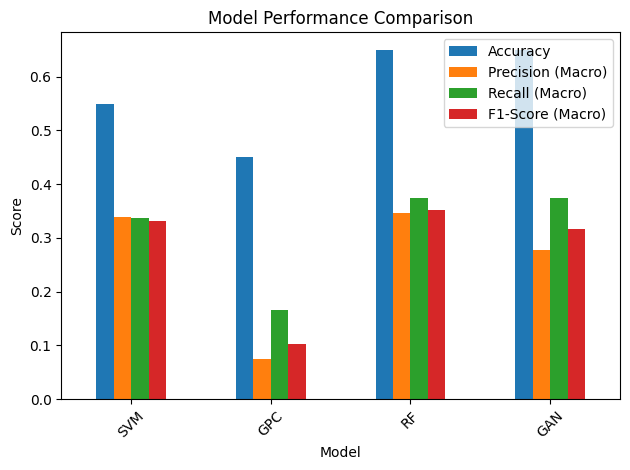

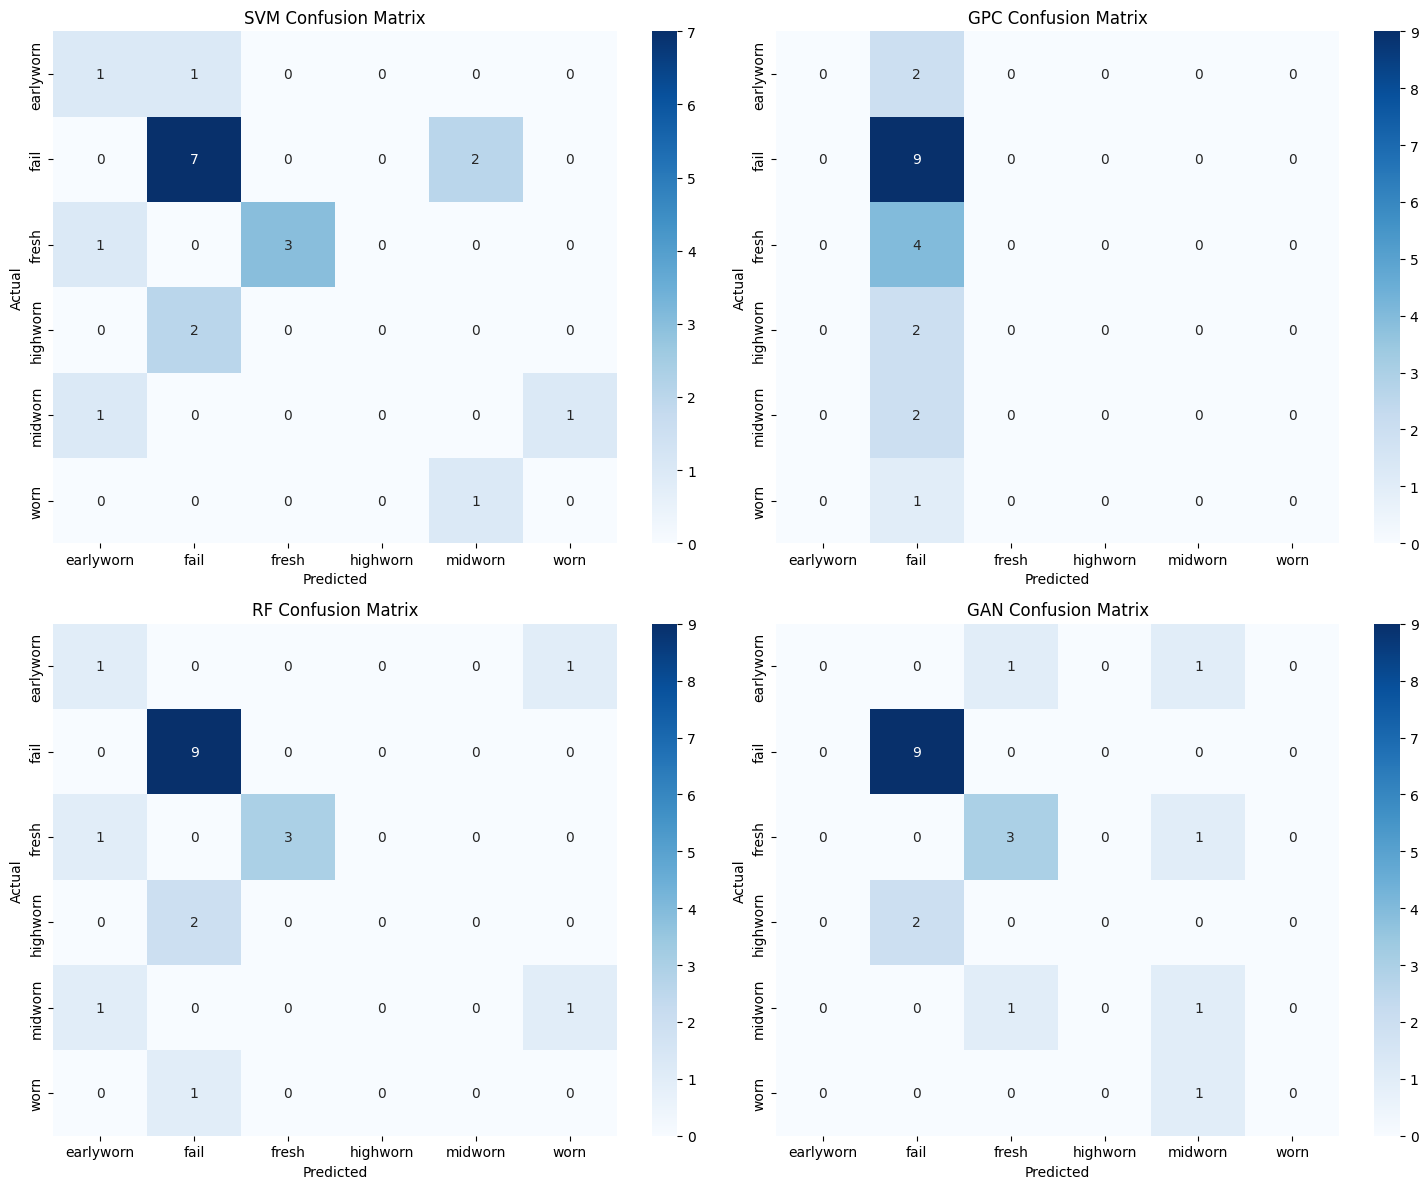

<Figure size 1000x600 with 0 Axes>

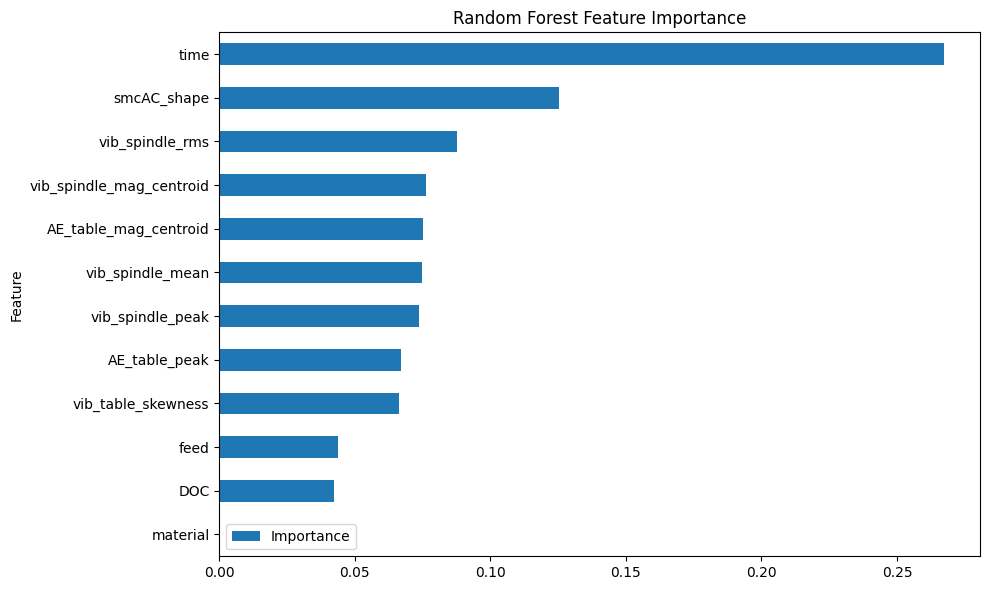


Final Model Performance:
  Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  \
0   SVM      0.55             0.3389          0.3380            0.3323   
1   GPC      0.45             0.0750          0.1667            0.1034   
2    RF      0.65             0.3472          0.3750            0.3524   
3   GAN      0.65             0.2780          0.3750            0.3167   

   ROC-AUC (Macro)  
0           0.7976  
1           0.5940  
2           0.8107  
3           0.8811  


In [ ]:
#Training all the evaluation models
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Reproducibility settings
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

class GANClassifier(Model):
    def __init__(self, num_classes, input_dim=12):
        super().__init__()
        self.num_classes = num_classes
        self.input_dim = input_dim

        # Generator
        self.generator = tf.keras.Sequential([
            layers.Dense(128, input_shape=(64,)),
            layers.LeakyReLU(0.2),
            layers.BatchNormalization(),
            layers.Dense(256),
            layers.LeakyReLU(0.2),
            layers.BatchNormalization(),
            layers.Dense(input_dim, activation='tanh')
        ])

        # Discriminator/Classifier
        self.discriminator = tf.keras.Sequential([
            layers.Dense(256, input_shape=(input_dim,)),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            layers.Dense(128),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            layers.Dense(1 + num_classes)
        ])

    def call(self, inputs):
        """Implementation of the forward pass"""
        return self.discriminator(inputs)

    def compile(self, g_optimizer, d_optimizer, loss_fn, **kwargs):
        # Add a dummy loss function to satisfy Keras requirements
        super().compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), **kwargs)
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn
        self.d_accuracy_metric = tf.keras.metrics.BinaryAccuracy()
        self.g_accuracy_metric = tf.keras.metrics.BinaryAccuracy()
        self.class_accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()

    @tf.function
    def train_step(self, data):
        x, y = data
        batch_size = tf.shape(x)[0]
        noise = tf.random.normal([batch_size, 64])

        # Train discriminator
        with tf.GradientTape() as disc_tape:
            # Real data
            d_real = self.discriminator(x)
            real_validity = d_real[:, 0]
            real_class = d_real[:, 1:]

            # Fake data
            fake_data = self.generator(noise)
            d_fake = self.discriminator(fake_data)
            fake_validity = d_fake[:, 0]

            # Discriminator losses
            d_loss_real = self.loss_fn(tf.ones_like(real_validity), real_validity)
            d_loss_fake = self.loss_fn(tf.zeros_like(fake_validity), fake_validity)
            d_loss_gan = (d_loss_real + d_loss_fake) / 2

            # Classification loss
            class_loss = tf.keras.losses.sparse_categorical_crossentropy(
                y, real_class, from_logits=True
            )

            # Total discriminator loss
            d_loss = d_loss_gan + tf.reduce_mean(class_loss)

        # Update discriminator
        d_grads = disc_tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_weights))

        # Train generator
        with tf.GradientTape() as gen_tape:
            fake_data = self.generator(noise)
            d_fake = self.discriminator(fake_data)
            fake_validity = d_fake[:, 0]
            g_loss = self.loss_fn(tf.ones_like(fake_validity), fake_validity)

        # Update generator
        g_grads = gen_tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_weights))

        # Update metrics
        self.d_accuracy_metric.update_state(tf.ones_like(real_validity), tf.sigmoid(real_validity))
        self.d_accuracy_metric.update_state(tf.zeros_like(fake_validity), tf.sigmoid(fake_validity))
        self.g_accuracy_metric.update_state(tf.ones_like(fake_validity), tf.sigmoid(fake_validity))
        self.class_accuracy_metric.update_state(y, real_class)

        return {
            "d_loss": d_loss_gan,
            "g_loss": g_loss,
            "class_loss": tf.reduce_mean(class_loss),
            "d_acc": self.d_accuracy_metric.result(),
            "g_acc": self.g_accuracy_metric.result(),
            "class_acc": self.class_accuracy_metric.result()
        }

    def predict(self, x):
        """Predict class labels"""
        d_out = self.discriminator(x)
        class_logits = d_out[:, 1:]  # Get only classification outputs
        return tf.argmax(class_logits, axis=1)

class ToolWearClassifier:
    def __init__(self):
        self.features = [
            'DOC', 'time', 'feed', 'material',
            'vib_spindle_rms', 'vib_spindle_mean', 'vib_spindle_peak',
            'AE_table_mag_centroid', 'smcAC_shape', 'vib_table_skewness',
            'vib_spindle_mag_centroid', 'AE_table_peak'
        ]
        self.le = LabelEncoder()
        self.imputer = SimpleImputer(strategy='mean')
        self.scaler = StandardScaler()
        self.models = {}
        self.results = []

    def load_data(self, synth_path, test_path):
        """Load and preprocess data"""
        self.synth_df = pd.read_csv(synth_path)
        self.test_df = pd.read_csv(test_path)

        # Encode classes
        self.synth_df['VB_class_encoded'] = self.le.fit_transform(self.synth_df['VB_class'])
        self.test_df['VB_class_encoded'] = self.le.transform(self.test_df['VB_class'])

        # Prepare features
        self.X_train = self.synth_df[self.features]
        self.y_train = self.synth_df['VB_class_encoded']
        self.X_test = self.test_df[self.features]
        self.y_test = self.test_df['VB_class_encoded']

        # Handle missing values and scale
        self.X_train = pd.DataFrame(
            self.imputer.fit_transform(self.X_train),
            columns=self.features
        )
        self.X_test = pd.DataFrame(
            self.imputer.transform(self.X_test),
            columns=self.features
        )

        self.X_train_sc = self.scaler.fit_transform(self.X_train)
        self.X_test_sc = self.scaler.transform(self.X_test)

    def evaluate_model(self, name, y_pred, y_pred_proba=None):
        """Enhanced evaluation metrics"""
        metrics = {
            'Model': name,
            'Accuracy': accuracy_score(self.y_test, y_pred),
            'Precision (Macro)': precision_score(self.y_test, y_pred, average='macro'),
            'Recall (Macro)': recall_score(self.y_test, y_pred, average='macro'),
            'F1-Score (Macro)': f1_score(self.y_test, y_pred, average='macro')
        }

        if y_pred_proba is not None:
            metrics['ROC-AUC (Macro)'] = roc_auc_score(
                tf.keras.utils.to_categorical(self.y_test),
                y_pred_proba,
                average='macro'
            )

        self.results.append(metrics)
        return metrics

    def train_svm(self):
        """Train SVM with optimized parameters"""
        print("Training SVM...")
        self.models['SVM'] = SVC(
            kernel='rbf',
            C=10,
            gamma='scale',
            probability=True,
            random_state=42
        )
        self.models['SVM'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['SVM'].predict(self.X_test_sc)
        y_pred_proba = self.models['SVM'].predict_proba(self.X_test_sc)
        return self.evaluate_model('SVM', y_pred, y_pred_proba)

    def train_gpc(self):
        """Train GPC with optimized kernel"""
        print("Training GPC...")
        kernel = C(1.0) * RBF(length_scale=1.0)
        self.models['GPC'] = GaussianProcessClassifier(
            kernel=kernel,
            random_state=42,
            n_jobs=-1
        )
        self.models['GPC'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['GPC'].predict(self.X_test_sc)
        y_pred_proba = self.models['GPC'].predict_proba(self.X_test_sc)
        return self.evaluate_model('GPC', y_pred, y_pred_proba)

    def train_rf(self):
        """Train Random Forest with optimized parameters"""
        print("Training RF...")
        self.models['RF'] = RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        self.models['RF'].fit(self.X_train_sc, self.y_train)
        y_pred = self.models['RF'].predict(self.X_test_sc)
        y_pred_proba = self.models['RF'].predict_proba(self.X_test_sc)
        return self.evaluate_model('RF', y_pred, y_pred_proba)

    def train_gan(self):
        """Train improved GAN classifier"""
        print("Training GAN...")
        num_classes = len(self.le.classes_)
        gan_clf = GANClassifier(num_classes=num_classes, input_dim=len(self.features))

        callbacks = [
            EarlyStopping(
                monitor='class_acc',
                patience=30,
                restore_best_weights=True,
                mode='max'
            ),
            ReduceLROnPlateau(
                monitor='class_acc',
                factor=0.5,
                patience=10,
                min_lr=1e-6,
                mode='max'
            )
        ]

        gan_clf.compile(
            g_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
            d_optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
            loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True)
        )

        history = gan_clf.fit(
            self.X_train_sc, self.y_train,
            epochs=500,
            batch_size=32,
            callbacks=callbacks,
            validation_split=0.2,
            verbose=1
        )

        self.models['GAN'] = gan_clf
        y_pred = gan_clf.predict(self.X_test_sc)
        d_out = gan_clf.discriminator(self.X_test_sc)
        y_pred_proba = tf.nn.softmax(d_out[:, 1:]).numpy()

        return self.evaluate_model('GAN', y_pred, y_pred_proba)

    def plot_results(self):
        """Enhanced visualization of results"""
        # 1. Model Performance Comparison
        results_df = pd.DataFrame(self.results)
        plt.figure(figsize=(12, 6))
        results_df.set_index('Model')[
            ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
        ].plot(kind='bar')
        plt.title('Model Performance Comparison')
        plt.ylabel('Score')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # 2. Confusion Matrices
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        for ax, (name, model) in zip(axes.flatten(), self.models.items()):
            if name == 'GAN':
                y_pred = model.predict(self.X_test_sc)
            else:
                y_pred = model.predict(self.X_test_sc)
            cm = confusion_matrix(self.y_test, y_pred)
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=self.le.classes_,
                yticklabels=self.le.classes_
            )
            ax.set_title(f'{name} Confusion Matrix')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')
        plt.tight_layout()
        plt.show()

        # 3. Feature Importance (for RF)
        if 'RF' in self.models:
            plt.figure(figsize=(10, 6))
            importances = self.models['RF'].feature_importances_
            feature_imp = pd.DataFrame({
                'Feature': self.features,
                'Importance': importances
            }).sort_values('Importance', ascending=True)

            feature_imp.plot(
                kind='barh',
                x='Feature',
                y='Importance',
                figsize=(10, 6)
            )
            plt.title('Random Forest Feature Importance')
            plt.tight_layout()
            plt.show()

def main():
    # Initialize classifier
    classifier = ToolWearClassifier()

    try:
        # Load data
        print("Loading and preprocessing data...")
        classifier.load_data(
            '/content/drive/MyDrive/ColabNotebooks/combined_real_synthetic_data_mat2_40.csv',
            '/content/drive/MyDrive/ColabNotebooks/Material2_Test_2cases.csv'
        )

        # Train all models
        print("\nTraining models...")
        classifier.train_svm()
        classifier.train_gpc()
        classifier.train_rf()
        classifier.train_gan()

        # Plot results
        print("\nGenerating visualizations...")
        classifier.plot_results()

        # Print final results
        results_df = pd.DataFrame(classifier.results)
        print("\nFinal Model Performance:")
        print(results_df.round(4))

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        raise

if __name__ == "__main__":
    main()

Testing different hyperparameter configurations...

Testing configuration: {'latent_dim': 32, 'g_hidden': [64, 128], 'd_hidden': [128, 64], 'dropout_rate': 0.3, 'n_critic': 1, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x79484d9a3650>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x7948526f08d0>, 'batch_size': 32}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - class_acc: 0.1087 - class_loss: 1.9150 - d_acc: 0.4586 - d_loss: 0.6756 - g_acc: 0.6999 - g_loss: 0.6678 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.1097 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - class_acc: 0.1087 - class_loss: 1.9000 - d_acc: 0.4318 - d_loss: 0.6789 - g_acc: 0.7709 - g_loss: 0.6669 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.1070 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - class_acc: 0.1087 - class_loss: 1.8857 - d_acc: 0.4549 - d_loss: 0.6790 - g_acc: 0.7419 - g_loss: 0.6624 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.1047 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - class_acc: 0.1087 - class_loss: 1.8718 - d_acc: 0.4129 - d_loss: 0.6737 - g_acc: 0.8354 - g_loss: 0.6583 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.1027 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - class_acc: 0.1182 - class_loss: 1.8581 - d_acc: 0.4158 - d_loss: 0.6703 - g_acc: 0.8471 - g_loss: 0.6529 - val_binar

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


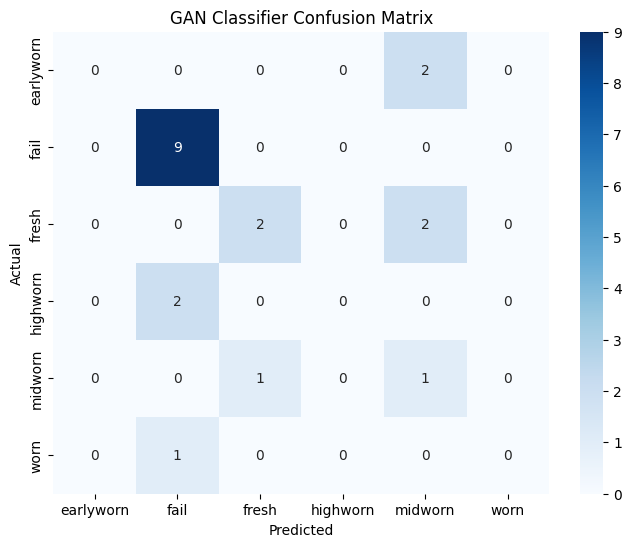

Results: {'accuracy': 0.6, 'precision': 0.26944444444444443, 'recall': 0.3333333333333333, 'f1': 0.28571428571428564, 'roc_auc': np.float64(0.7933570906432749), 'config': {'latent_dim': 32, 'g_hidden': [64, 128], 'd_hidden': [128, 64], 'dropout_rate': 0.3, 'n_critic': 1, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x79484d9a3650>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x7948526f08d0>, 'batch_size': 32}, 'epochs_trained': 100}

Testing configuration: {'latent_dim': 64, 'g_hidden': [128, 256], 'd_hidden': [256, 128], 'dropout_rate': 0.3, 'n_critic': 1, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x7948503cced0>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x794849ab4810>, 'batch_size': 32}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - class_acc: 0.0879 - class_loss: 1.8247 - d_acc: 0.3740 - d_loss: 0.7091 - g_acc: 0.8388 - g_loss: 0.6499 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0383 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - class_acc: 0.1399 - class_loss: 1.8055 - d_acc: 0.3382 - d_loss: 0.7029 - g_acc: 0.9199 - g_loss: 0.6525 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0365 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - class_acc: 0.1897 - class_loss: 1.7875 - d_acc: 0.3432 - d_loss: 0.7084 - g_acc: 0.9770 - g_loss: 0.6444 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0351 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - class_acc: 0.2620 - class_loss: 1.7701 - d_acc: 0.3567 - d_loss: 0.7066 - g_acc: 0.9944 - g_loss: 0.6449 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0342 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - class_acc: 0.2945 - class_loss: 1.7532 - d_acc: 0.3835 - d_loss: 0.7042 - g_acc: 0.9905 - g_loss: 0.6319 - val_binary_ac

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


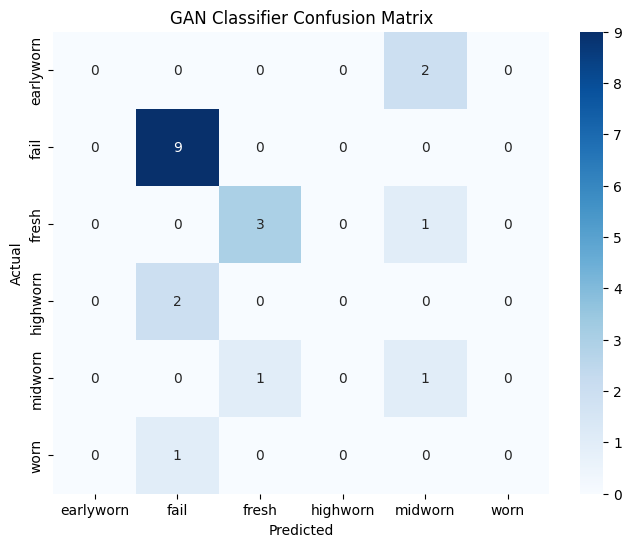

Results: {'accuracy': 0.65, 'precision': 0.2916666666666667, 'recall': 0.375, 'f1': 0.32341269841269843, 'roc_auc': np.float64(0.9165752923976608), 'config': {'latent_dim': 64, 'g_hidden': [128, 256], 'd_hidden': [256, 128], 'dropout_rate': 0.3, 'n_critic': 1, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x7948503cced0>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x794849ab4810>, 'batch_size': 32}, 'epochs_trained': 100}

Testing configuration: {'latent_dim': 128, 'g_hidden': [256, 512], 'd_hidden': [512, 256], 'dropout_rate': 0.3, 'n_critic': 1, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x79485269a8d0>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x79484fb8fd50>, 'batch_size': 32}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 963ms/step - class_acc: 0.1719 - class_loss: 1.8052 - d_acc: 0.6694 - d_loss: 0.6550 - g_acc: 0.5443 - g_loss: 0.6868 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0490 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - class_acc: 0.2559 - class_loss: 1.7665 - d_acc: 0.5795 - d_loss: 0.6544 - g_acc: 0.7414 - g_loss: 0.6724 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0417 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - class_acc: 0.2845 - class_loss: 1.7311 - d_acc: 0.5221 - d_loss: 0.6609 - g_acc: 0.8657 - g_loss: 0.6542 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0366 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - class_acc: 0.3876 - class_loss: 1.6979 - d_acc: 0.4731 - d_loss: 0.6619 - g_acc: 0.9731 - g_loss: 0.6427 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0339 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - class_acc: 0.3954 - class_loss: 1.6668 - d_acc: 0.4866 - d_loss: 0.6631 - g_acc: 0.9558 - g_loss: 0.6236 - val_binar

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


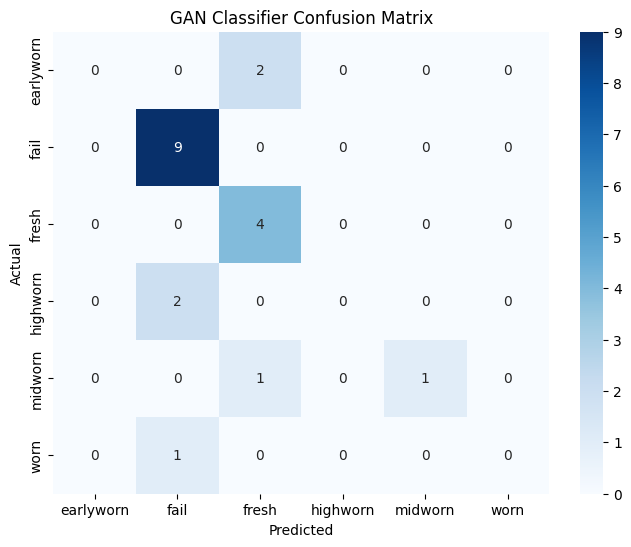

Results: {'accuracy': 0.7, 'precision': 0.38690476190476186, 'recall': 0.4166666666666667, 'f1': 0.3751803751803751, 'roc_auc': np.float64(0.9124329922027291), 'config': {'latent_dim': 128, 'g_hidden': [256, 512], 'd_hidden': [512, 256], 'dropout_rate': 0.3, 'n_critic': 1, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x79485269a8d0>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x79484fb8fd50>, 'batch_size': 32}, 'epochs_trained': 100}

Testing configuration: {'latent_dim': 64, 'g_hidden': [128, 256], 'd_hidden': [256, 128], 'dropout_rate': 0.3, 'n_critic': 1, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x79484fcc2590>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x7948502bd790>, 'batch_size': 64}
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - class_acc: 0.1869 - class_loss: 1.7703 - d_acc: 0.4810 - d_loss: 0.6747 - g_acc: 0.9544 - g_loss: 0.6449 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9655 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - class_acc: 0.3768 - class_loss: 1.6406 - d_acc: 0.4937 - d_loss: 0.6750 - g_acc: 1.0000 - g_loss: 0.6069 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0024 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - class_acc: 0.4201 - class_loss: 1.5375 - d_acc: 0.5000 - d_loss: 0.6726 - g_acc: 1.0000 - g_loss: 0.5980 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0535 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - class_acc: 0.4276 - class_loss: 1.4531 - d_acc: 0.5213 - d_loss: 0.6373 - g_acc: 0.9573 - g_loss: 0.6429 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.1165 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - class_acc: 0.4350 - class_loss: 1.3840 - d_acc: 0.8020 - d_loss: 0.5843 - g_acc: 0.3960 - g_loss: 0.7280 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.1916 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - class_acc: 0.4477 - class_loss: 1.3262 - d_acc: 0.9582 - d_loss: 0.5445 - g_acc: 0.0710 - g_loss: 0.8086 - val_binar

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


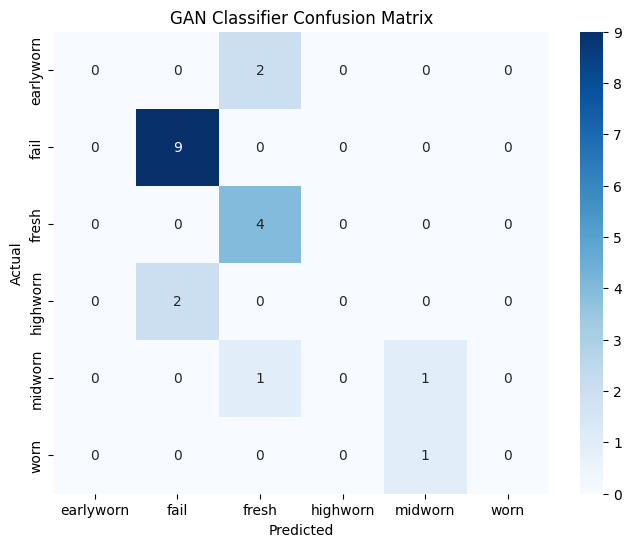

Results: {'accuracy': 0.7, 'precision': 0.3149350649350649, 'recall': 0.4166666666666667, 'f1': 0.35454545454545455, 'roc_auc': np.float64(0.883497807017544), 'config': {'latent_dim': 64, 'g_hidden': [128, 256], 'd_hidden': [256, 128], 'dropout_rate': 0.3, 'n_critic': 1, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x79484fcc2590>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x7948502bd790>, 'batch_size': 64}, 'epochs_trained': 100}

Testing configuration: {'latent_dim': 64, 'g_hidden': [128, 256], 'd_hidden': [256, 128], 'dropout_rate': 0.3, 'n_critic': 1, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x7948502b1090>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x794850378150>, 'batch_size': 32}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - class_acc: 0.2676 - class_loss: 1.7812 - d_acc: 0.5190 - d_loss: 0.6744 - g_acc: 0.6501 - g_loss: 0.6858 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9693 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - class_acc: 0.3001 - class_loss: 1.7627 - d_acc: 0.4281 - d_loss: 0.6700 - g_acc: 0.8493 - g_loss: 0.6687 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9738 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - class_acc: 0.3690 - class_loss: 1.7454 - d_acc: 0.4487 - d_loss: 0.6734 - g_acc: 0.8445 - g_loss: 0.6581 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9786 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - class_acc: 0.3517 - class_loss: 1.7287 - d_acc: 0.4149 - d_loss: 0.6736 - g_acc: 0.9524 - g_loss: 0.6537 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9839 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - class_acc: 0.3517 - class_loss: 1.7125 - d_acc: 0.4034 - d_loss: 0.6732 - g_acc: 0.9810 - g_loss: 0.6377 - val_binary_ac

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


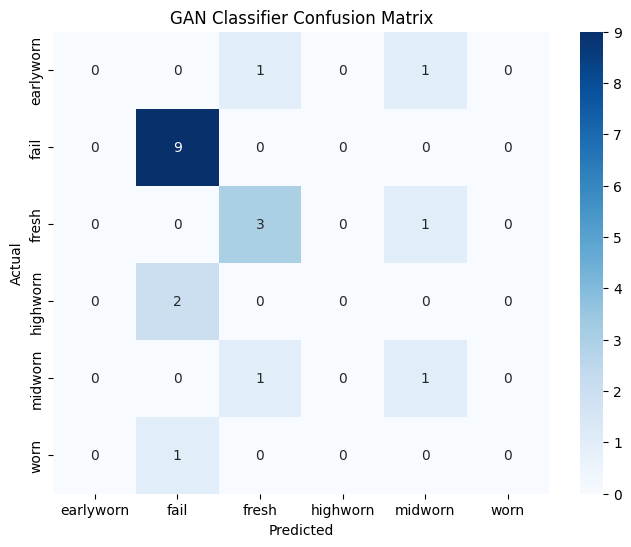

Results: {'accuracy': 0.65, 'precision': 0.28055555555555556, 'recall': 0.375, 'f1': 0.3206349206349206, 'roc_auc': np.float64(0.900660940545809), 'config': {'latent_dim': 64, 'g_hidden': [128, 256], 'd_hidden': [256, 128], 'dropout_rate': 0.3, 'n_critic': 1, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x7948502b1090>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x794850378150>, 'batch_size': 32}, 'epochs_trained': 100}

Testing configuration: {'latent_dim': 64, 'g_hidden': [128, 256], 'd_hidden': [256, 128], 'dropout_rate': 0.3, 'n_critic': 1, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x794850d82cd0>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x794850005190>, 'batch_size': 16}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 481ms/step - class_acc: 0.3335 - class_loss: 1.6828 - d_acc: 0.3575 - d_loss: 0.7417 - g_acc: 0.4710 - g_loss: 0.6991 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9591 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - class_acc: 0.3335 - class_loss: 1.6797 - d_acc: 0.2982 - d_loss: 0.7392 - g_acc: 0.6042 - g_loss: 0.6924 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9595 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - class_acc: 0.3335 - class_loss: 1.6768 - d_acc: 0.3697 - d_loss: 0.7375 - g_acc: 0.4611 - g_loss: 0.6944 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9599 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - class_acc: 0.3335 - class_loss: 1.6740 - d_acc: 0.2778 - d_loss: 0.7422 - g_acc: 0.6500 - g_loss: 0.6892 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9603 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - class_acc: 0.3335 - class_loss: 1.6712 - d_acc: 0.3027 - d_loss: 0.7334 - g_acc: 0.6075 - g_loss: 0.6894 - val_binary_ac

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


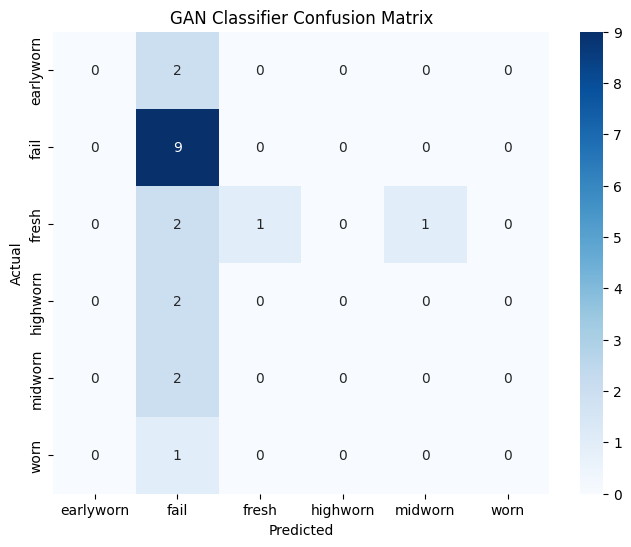

Results: {'accuracy': 0.5, 'precision': 0.25, 'recall': 0.20833333333333334, 'f1': 0.17777777777777778, 'roc_auc': np.float64(0.8695549242424242), 'config': {'latent_dim': 64, 'g_hidden': [128, 256], 'd_hidden': [256, 128], 'dropout_rate': 0.3, 'n_critic': 1, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x794850d82cd0>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x794850005190>, 'batch_size': 16}, 'epochs_trained': 100}

Testing configuration: {'latent_dim': 64, 'g_hidden': [128, 256], 'd_hidden': [256, 128], 'dropout_rate': 0.2, 'n_critic': 3, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x7948502e41d0>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x79485032a5d0>, 'batch_size': 32}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - class_acc: 0.2234 - class_loss: 1.7265 - d_acc: 0.3488 - d_loss: 0.7100 - g_acc: 0.9675 - g_loss: 0.6432 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0308 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - class_acc: 0.3517 - class_loss: 1.6774 - d_acc: 0.4090 - d_loss: 0.6909 - g_acc: 0.9446 - g_loss: 0.6451 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0409 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - class_acc: 0.4339 - class_loss: 1.6330 - d_acc: 0.4894 - d_loss: 0.6761 - g_acc: 0.9714 - g_loss: 0.6516 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0555 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - class_acc: 0.4608 - class_loss: 1.5920 - d_acc: 0.5104 - d_loss: 0.6585 - g_acc: 0.9446 - g_loss: 0.6571 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0736 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - class_acc: 0.4608 - class_loss: 1.5548 - d_acc: 0.5390 - d_loss: 0.6442 - g_acc: 0.9221 - g_loss: 0.6632 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0949 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - class_acc: 0.4435 - class_loss: 1.5213 - d_acc: 0.5983 - d_loss: 0.6278 - g_acc: 0.8034 - g_loss: 0.6712 - val_binary_ac

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


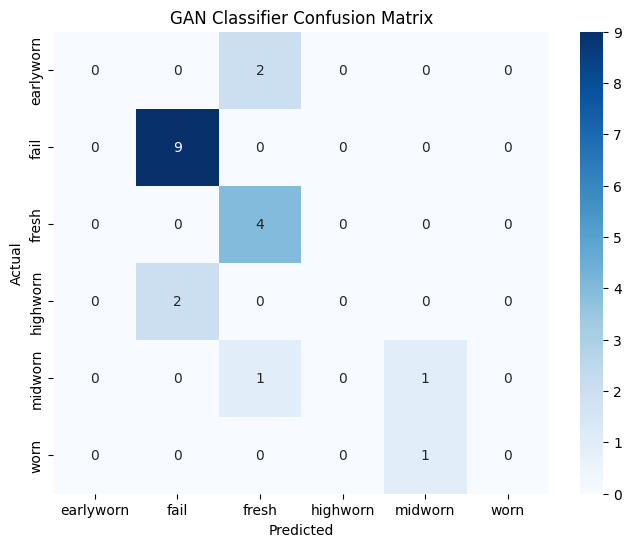

Results: {'accuracy': 0.7, 'precision': 0.3149350649350649, 'recall': 0.4166666666666667, 'f1': 0.35454545454545455, 'roc_auc': np.float64(0.9171539961013645), 'config': {'latent_dim': 64, 'g_hidden': [128, 256], 'd_hidden': [256, 128], 'dropout_rate': 0.2, 'n_critic': 3, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x7948502e41d0>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x79485032a5d0>, 'batch_size': 32}, 'epochs_trained': 100}

Testing configuration: {'latent_dim': 64, 'g_hidden': [128, 256], 'd_hidden': [256, 128], 'dropout_rate': 0.4, 'n_critic': 3, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x794850185f50>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x7948503529d0>, 'batch_size': 32}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - class_acc: 0.2625 - class_loss: 1.7737 - d_acc: 0.5048 - d_loss: 0.6626 - g_acc: 0.8965 - g_loss: 0.6485 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0050 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - class_acc: 0.2720 - class_loss: 1.7229 - d_acc: 0.4902 - d_loss: 0.6568 - g_acc: 0.9485 - g_loss: 0.6507 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0218 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - class_acc: 0.3599 - class_loss: 1.6771 - d_acc: 0.4913 - d_loss: 0.6459 - g_acc: 0.9731 - g_loss: 0.6416 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0409 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - class_acc: 0.4088 - class_loss: 1.6349 - d_acc: 0.5353 - d_loss: 0.6338 - g_acc: 0.9026 - g_loss: 0.6554 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0614 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - class_acc: 0.4647 - class_loss: 1.5961 - d_acc: 0.5401 - d_loss: 0.6273 - g_acc: 0.9199 - g_loss: 0.6457 - val_binary_

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


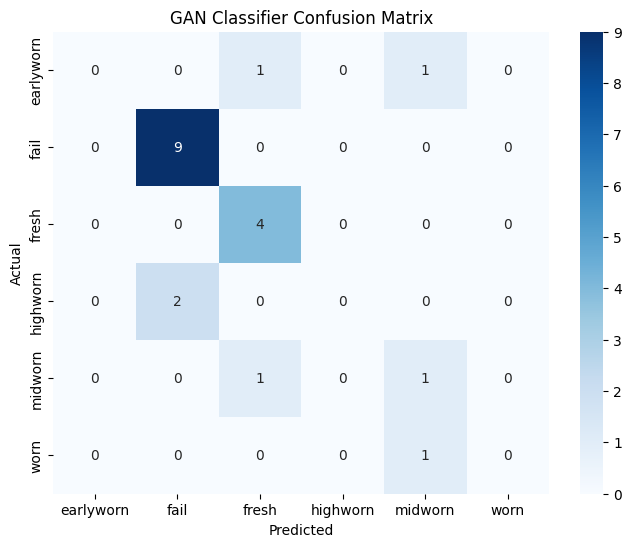

Results: {'accuracy': 0.7, 'precision': 0.30303030303030304, 'recall': 0.4166666666666667, 'f1': 0.35000000000000003, 'roc_auc': np.float64(0.9130116959064326), 'config': {'latent_dim': 64, 'g_hidden': [128, 256], 'd_hidden': [256, 128], 'dropout_rate': 0.4, 'n_critic': 3, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x794850185f50>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x7948503529d0>, 'batch_size': 32}, 'epochs_trained': 100}

Testing configuration: {'latent_dim': 64, 'g_hidden': [128, 256], 'd_hidden': [256, 128], 'dropout_rate': 0.3, 'n_critic': 1, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x79484f877b50>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x7948ff4bd950>, 'batch_size': 32}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 951ms/step - class_acc: 0.2356 - class_loss: 1.8081 - d_acc: 0.5173 - d_loss: 0.6953 - g_acc: 0.5941 - g_loss: 0.6897 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0307 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - class_acc: 0.2547 - class_loss: 1.7871 - d_acc: 0.5106 - d_loss: 0.6968 - g_acc: 0.6076 - g_loss: 0.6785 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0310 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - class_acc: 0.2928 - class_loss: 1.7675 - d_acc: 0.4359 - d_loss: 0.6968 - g_acc: 0.7744 - g_loss: 0.6654 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0316 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - class_acc: 0.3292 - class_loss: 1.7485 - d_acc: 0.4034 - d_loss: 0.6956 - g_acc: 0.8449 - g_loss: 0.6605 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0327 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - class_acc: 0.3387 - class_loss: 1.7300 - d_acc: 0.3766 - d_loss: 0.6990 - g_acc: 0.8987 - g_loss: 0.6523 - val_binary_accuracy: 0.0000e+00 - val_loss: 2.0341 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - class_acc: 0.3538 - class_loss: 1.7121 - d_acc: 0.3855 - d_loss: 0.6984 - g_acc: 0.9038 - g_loss: 0.6466 - val_binary_ac

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


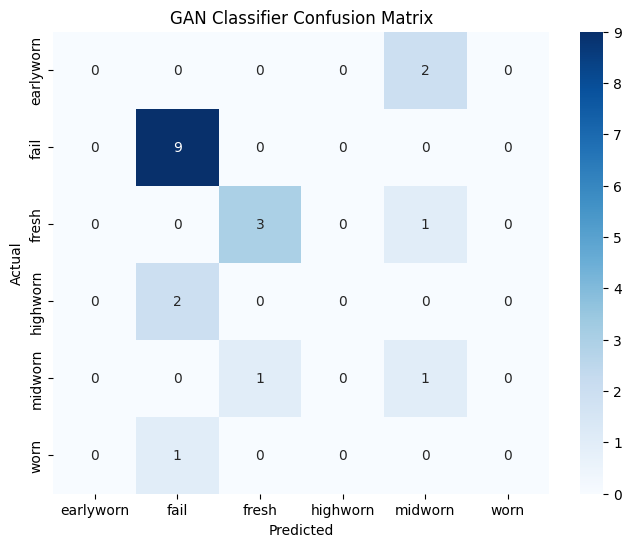

Results: {'accuracy': 0.65, 'precision': 0.2916666666666667, 'recall': 0.375, 'f1': 0.32341269841269843, 'roc_auc': np.float64(0.8573647660818713), 'config': {'latent_dim': 64, 'g_hidden': [128, 256], 'd_hidden': [256, 128], 'dropout_rate': 0.3, 'n_critic': 1, 'g_optimizer': <keras.src.optimizers.adam.Adam object at 0x79484f877b50>, 'd_optimizer': <keras.src.optimizers.adam.Adam object at 0x7948ff4bd950>, 'batch_size': 32}, 'epochs_trained': 100}

Saved results to gan_test_results_20250731_200514.csv

Hyperparameter Analysis:

Best configuration (accuracy=0.7000):
{
  "latent_dim": 128,
  "g_hidden": [
    256,
    512
  ],
  "d_hidden": [
    512,
    256
  ],
  "dropout_rate": 0.3,
  "n_critic": 1,
  "g_optimizer": "Adam(lr=9.999999747378752e-05)",
  "d_optimizer": "Adam(lr=9.999999747378752e-05)",
  "batch_size": 32
}


,Config ID,Latent Dim,G Hidden,D Hidden,Dropout,Batch Size,Learning Rate,n_critic,Accuracy,F1 Score,Epochs Trained
2,2,128,256-512,512-256,0.3000,32,0.0001,1,0.7000,0.3752,100
7,7,64,128-256,256-128,0.4000,32,0.0001,3,0.7000,0.3500,100
3,3,64,128-256,256-128,0.3000,64,0.0010,1,0.7000,0.3545,100
6,6,64,128-256,256-128,0.2000,32,0.0001,3,0.7000,0.3545,100
4,4,64,128-256,256-128,0.3000,32,0.0001,1,0.6500,0.3206,100
8,8,64,128-256,256-128,0.3000,32,0.0001,1,0.6500,0.3234,100
1,1,64,128-256,256-128,0.3000,32,0.0001,1,0.6500,0.3234,100
0,0,32,64-128,128-64,0.3000,32,0.0001,1,0.6000,0.2857,100
5,5,64,128-256,256-128,0.3000,16,0.0000,1,0.5000,0.1778,100


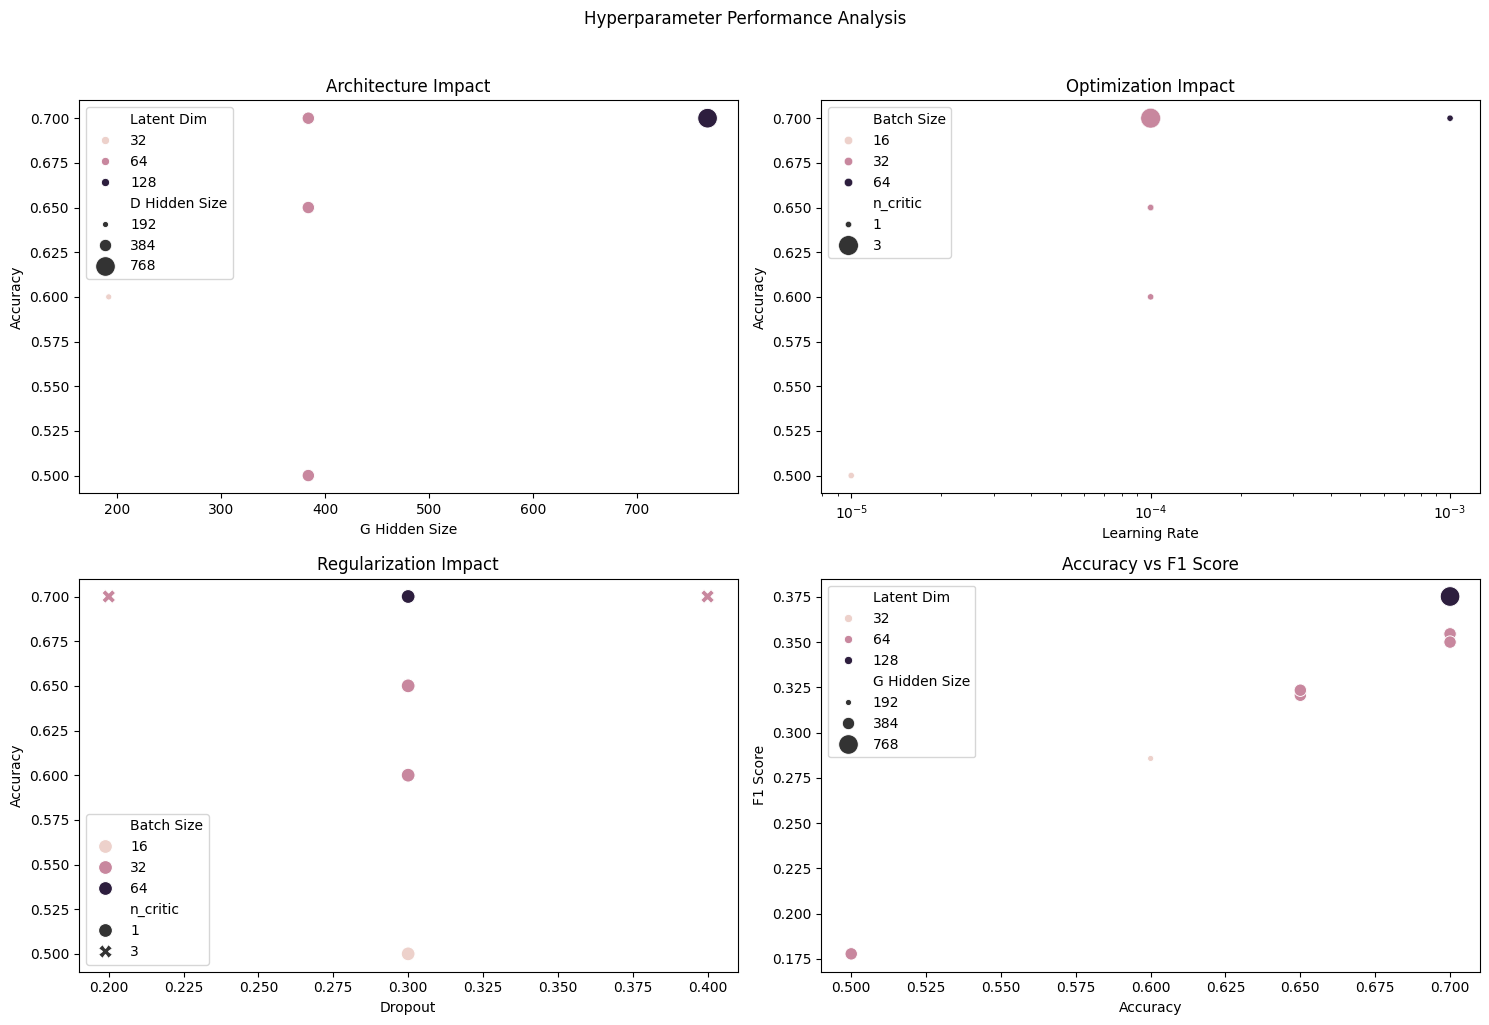


Hyperparameter tuning complete. Best configuration saved to 'best_gan_config.json'

Training with best configuration...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/290
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - class_acc: 0.0723 - class_loss: 1.7925 - d_acc: 0.5048 - d_loss: 0.7044 - g_acc: 0.0381 - g_loss: 0.7402 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9881 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/290
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - class_acc: 0.0938 - class_loss: 1.7750 - d_acc: 0.5469 - d_loss: 0.7067 - g_acc: 0.0312 - g_loss: 0.7340

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_class_acc` which is not available. Available metrics are: class_acc,class_loss,d_acc,d_loss,g_acc,g_loss,val_binary_accuracy,val_loss,val_sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - class_acc: 0.1580 - class_loss: 1.7606 - d_acc: 0.5319 - d_loss: 0.7063 - g_acc: 0.0852 - g_loss: 0.7173 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9905 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/290
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - class_acc: 0.3018 - class_loss: 1.7314 - d_acc: 0.3690 - d_loss: 0.7072 - g_acc: 0.4855 - g_loss: 0.6941 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9944 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/290
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - class_acc: 0.3802 - class_loss: 1.7036 - d_acc: 0.3740 - d_loss: 0.7116 - g_acc: 0.6669 - g_loss: 0.6715 - val_binary_accuracy: 0.0000e+00 - val_loss: 1.9997 - val_sparse_categorical_accuracy: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/290
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - class_acc: 0.4357 - class_loss: 1.6769 - d_acc: 0.3060 - d_loss: 0.7105 - g_acc: 0.9138 - g_loss: 0.6478 - val_binary_ac

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


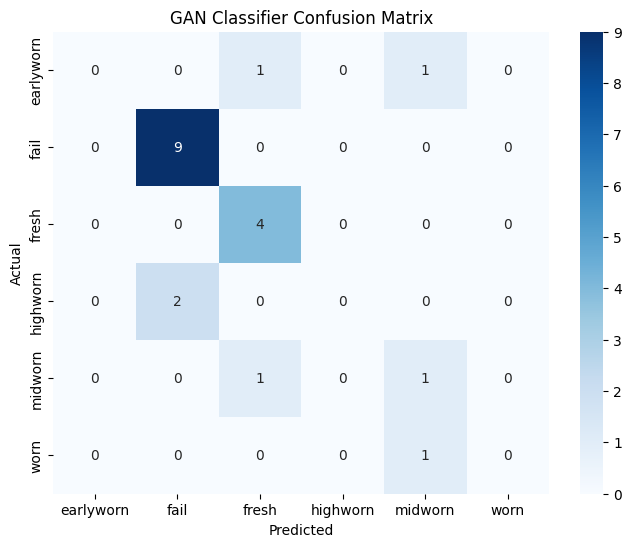


Final GAN Classifier Performance:
accuracy: 0.7000
precision: 0.3030
recall: 0.4167
f1: 0.3500
roc_auc: 0.8991


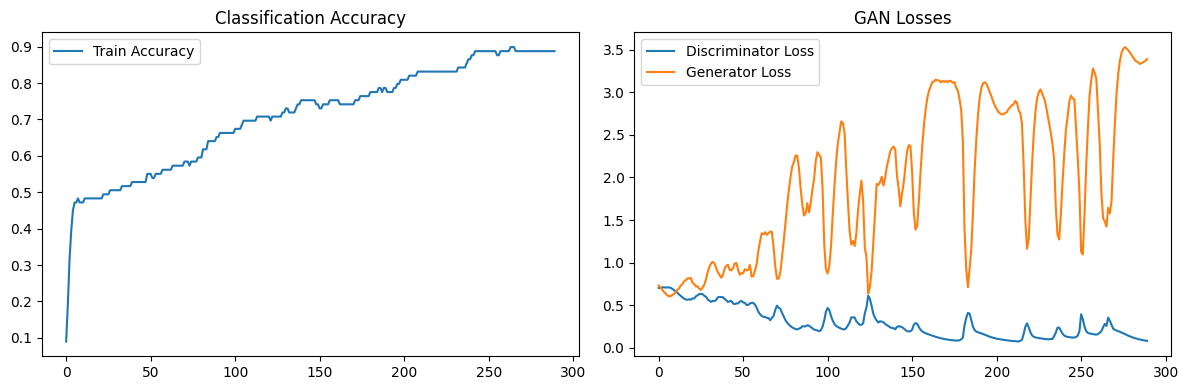

from matplotlib import pyplot as plt
_df_0['Config ID'].plot(kind='hist', bins=20, title='Config ID')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Latent Dim'].plot(kind='hist', bins=20, title='Latent Dim')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Dropout'].plot(kind='hist', bins=20, title='Dropout')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['Batch Size'].plot(kind='hist', bins=20, title='Batch Size')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_4.groupby('G Hidden').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_20['D Hidden'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_20, x='Config ID', y='D Hidden', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_21['G Hidden'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_21, x='Latent Dim', y='G Hidden', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_22['D Hidden'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_22, x='Latent Dim', y='D Hidden', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
#Optimizing the GAN
import os
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
from datetime import datetime

# Set random seeds for reproducibility
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
np.random.seed(42)
tf.random.set_seed(42)

class GANClassifier(Model):
    """
    A GAN-based classifier that combines generative and discriminative learning.
    Now with configurable hyperparameters for testing.
    """
    def __init__(self, num_classes, input_dim=12, latent_dim=64,
                 g_hidden=[128, 256], d_hidden=[256, 128],
                 dropout_rate=0.3, leaky_relu_alpha=0.2):
        super().__init__()
        self.num_classes = num_classes
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.dropout_rate = dropout_rate
        self.leaky_relu_alpha = leaky_relu_alpha

        # Generator network
        self.generator = self._build_generator(g_hidden)

        # Discriminator/Classifier network
        self.discriminator = self._build_discriminator(d_hidden)

        # Metrics trackers
        self.d_accuracy_metric = tf.keras.metrics.BinaryAccuracy()
        self.g_accuracy_metric = tf.keras.metrics.BinaryAccuracy()
        self.class_accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()

    def _build_generator(self, hidden_units):
        """Build the generator network"""
        model = tf.keras.Sequential()
        model.add(layers.InputLayer(input_shape=(self.latent_dim,)))

        for units in hidden_units:
            model.add(layers.Dense(units))
            model.add(layers.LeakyReLU(self.leaky_relu_alpha))
            model.add(layers.BatchNormalization())

        model.add(layers.Dense(self.input_dim, activation='tanh'))
        return model

    def _build_discriminator(self, hidden_units):
        """Build the discriminator/classifier network"""
        model = tf.keras.Sequential()
        model.add(layers.InputLayer(input_shape=(self.input_dim,)))

        for units in hidden_units:
            model.add(layers.Dense(units))
            model.add(layers.LeakyReLU(self.leaky_relu_alpha))
            model.add(layers.Dropout(self.dropout_rate))

        # Output layer: 1 for real/fake + num_classes for classification
        model.add(layers.Dense(1 + self.num_classes))
        return model

    def call(self, inputs):
        """Forward pass - returns discriminator outputs"""
        return self.discriminator(inputs)

    def compile(self, g_optimizer, d_optimizer, loss_fn, n_critic=1, **kwargs):
        """Configure the training setup"""
        super().compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), **kwargs)
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn
        self.n_critic = n_critic  # Number of critic iterations per generator iteration

    @tf.function
    def train_step(self, data):
        """Single training step"""
        x, y = data
        batch_size = tf.shape(x)[0]

        # Train discriminator (n_critic times)
        for _ in range(self.n_critic):
            # Generate random noise for generator
            noise = tf.random.normal([batch_size, self.latent_dim])

            with tf.GradientTape() as disc_tape:
                # Real data
                d_real = self.discriminator(x)
                real_validity = d_real[:, 0]  # Real/fake output
                real_class = d_real[:, 1:]    # Class outputs

                # Fake data
                fake_data = self.generator(noise)
                d_fake = self.discriminator(fake_data)
                fake_validity = d_fake[:, 0]

                # Discriminator losses
                d_loss_real = self.loss_fn(tf.ones_like(real_validity), real_validity)
                d_loss_fake = self.loss_fn(tf.zeros_like(fake_validity), fake_validity)
                d_loss_gan = (d_loss_real + d_loss_fake) / 2

                # Classification loss
                class_loss = tf.keras.losses.sparse_categorical_crossentropy(
                    y, real_class, from_logits=True
                )

                # Total discriminator loss
                d_loss = d_loss_gan + tf.reduce_mean(class_loss)

            # Update discriminator
            d_grads = disc_tape.gradient(d_loss, self.discriminator.trainable_weights)
            self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_weights))

        # Train generator
        noise = tf.random.normal([batch_size, self.latent_dim])
        with tf.GradientTape() as gen_tape:
            fake_data = self.generator(noise)
            d_fake = self.discriminator(fake_data)
            fake_validity = d_fake[:, 0]
            g_loss = self.loss_fn(tf.ones_like(fake_validity), fake_validity)

        # Update generator
        g_grads = gen_tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_weights))

        # Update metrics
        self.d_accuracy_metric.update_state(tf.ones_like(real_validity), tf.sigmoid(real_validity))
        self.d_accuracy_metric.update_state(tf.zeros_like(fake_validity), tf.sigmoid(fake_validity))
        self.g_accuracy_metric.update_state(tf.ones_like(fake_validity), tf.sigmoid(fake_validity))
        self.class_accuracy_metric.update_state(y, real_class)

        return {
            "d_loss": d_loss_gan,
            "g_loss": g_loss,
            "class_loss": tf.reduce_mean(class_loss),
            "d_acc": self.d_accuracy_metric.result(),
            "g_acc": self.g_accuracy_metric.result(),
            "class_acc": self.class_accuracy_metric.result()
        }

    def predict(self, x):
        """Predict class labels"""
        d_out = self.discriminator(x)
        class_logits = d_out[:, 1:]  # Get only classification outputs
        return tf.argmax(class_logits, axis=1)

    def predict_proba(self, x):
        """Predict class probabilities"""
        d_out = self.discriminator(x)
        class_logits = d_out[:, 1:]
        return tf.nn.softmax(class_logits).numpy()

class GANTrainer:
    """Helper class for training and evaluating the GAN classifier with hyperparameter testing"""
    def __init__(self, features, target_col='VB_class'):
        self.features = features
        self.target_col = target_col
        self.le = LabelEncoder()
        self.imputer = SimpleImputer(strategy='mean')
        self.scaler = StandardScaler()

    def load_data(self, train_path, test_path):
        """Load and preprocess data"""
        train_df = pd.read_csv(train_path)
        test_df = pd.read_csv(test_path)

        # Encode classes
        train_df['target_encoded'] = self.le.fit_transform(train_df[self.target_col])
        test_df['target_encoded'] = self.le.transform(test_df[self.target_col])

        # Prepare features
        X_train = train_df[self.features]
        y_train = train_df['target_encoded']
        X_test = test_df[self.features]
        y_test = test_df['target_encoded']

        # Handle missing values and scale
        X_train = pd.DataFrame(
            self.imputer.fit_transform(X_train),
            columns=self.features
        )
        X_test = pd.DataFrame(
            self.imputer.transform(X_test),
            columns=self.features
        )

        self.X_train_sc = self.scaler.fit_transform(X_train)
        self.X_test_sc = self.scaler.transform(X_test)
        self.y_train = y_train.values
        self.y_test = y_test.values

        return self.X_train_sc, self.y_train, self.X_test_sc, self.y_test

    def get_test_configurations(self):
        """Generate different hyperparameter configurations to test"""
        return [
            # Architecture variations
            {
                'latent_dim': 32,
                'g_hidden': [64, 128],
                'd_hidden': [128, 64],
                'dropout_rate': 0.3,
                'n_critic': 1,
                'g_optimizer': optimizers.Adam(1e-4),
                'd_optimizer': optimizers.Adam(1e-4),
                'batch_size': 32
            },
            {
                'latent_dim': 64,
                'g_hidden': [128, 256],
                'd_hidden': [256, 128],
                'dropout_rate': 0.3,
                'n_critic': 1,
                'g_optimizer': optimizers.Adam(1e-4),
                'd_optimizer': optimizers.Adam(1e-4),
                'batch_size': 32
            },
            {
                'latent_dim': 128,
                'g_hidden': [256, 512],
                'd_hidden': [512, 256],
                'dropout_rate': 0.3,
                'n_critic': 1,
                'g_optimizer': optimizers.Adam(1e-4),
                'd_optimizer': optimizers.Adam(1e-4),
                'batch_size': 32
            },

            # Optimization variations
            {
                'latent_dim': 64,
                'g_hidden': [128, 256],
                'd_hidden': [256, 128],
                'dropout_rate': 0.3,
                'n_critic': 1,
                'g_optimizer': optimizers.Adam(1e-3),
                'd_optimizer': optimizers.Adam(1e-3),
                'batch_size': 64
            },
            {
                'latent_dim': 64,
                'g_hidden': [128, 256],
                'd_hidden': [256, 128],
                'dropout_rate': 0.3,
                'n_critic': 1,
                'g_optimizer': optimizers.Adam(1e-4),
                'd_optimizer': optimizers.Adam(1e-4),
                'batch_size': 32
            },
            {
                'latent_dim': 64,
                'g_hidden': [128, 256],
                'd_hidden': [256, 128],
                'dropout_rate': 0.3,
                'n_critic': 1,
                'g_optimizer': optimizers.Adam(1e-5),
                'd_optimizer': optimizers.Adam(1e-5),
                'batch_size': 16
            },

            # Regularization variations
            {
                'latent_dim': 64,
                'g_hidden': [128, 256],
                'd_hidden': [256, 128],
                'dropout_rate': 0.2,
                'n_critic': 3,
                'g_optimizer': optimizers.Adam(1e-4),
                'd_optimizer': optimizers.Adam(1e-4),
                'batch_size': 32
            },
            {
                'latent_dim': 64,
                'g_hidden': [128, 256],
                'd_hidden': [256, 128],
                'dropout_rate': 0.4,
                'n_critic': 3,
                'g_optimizer': optimizers.Adam(1e-4),
                'd_optimizer': optimizers.Adam(1e-4),
                'batch_size': 32
            },

            # Final candidate (default)
            {
                'latent_dim': 64,
                'g_hidden': [128, 256],
                'd_hidden': [256, 128],
                'dropout_rate': 0.3,
                'n_critic': 1,
                'g_optimizer': optimizers.Adam(1e-4),
                'd_optimizer': optimizers.Adam(1e-4),
                'batch_size': 32
            }
        ]

    def train_gan(self, X_train, y_train, num_classes, input_dim,
                 epochs=500, batch_size=32, validation_split=0.2, config=None):
        """Train the GAN classifier with optional configuration"""
        if config is None:
            config = {
                'latent_dim': 64,
                'g_hidden': [128, 256],
                'd_hidden': [256, 128],
                'dropout_rate': 0.3,
                'leaky_relu_alpha': 0.2
            }

        gan_clf = GANClassifier(
            num_classes=num_classes,
            input_dim=input_dim,
            latent_dim=config.get('latent_dim', 64),
            g_hidden=config.get('g_hidden', [128, 256]),
            d_hidden=config.get('d_hidden', [256, 128]),
            dropout_rate=config.get('dropout_rate', 0.3),
            leaky_relu_alpha=config.get('leaky_relu_alpha', 0.2)
        )

        callbacks = [
            EarlyStopping(
                monitor='val_class_acc',
                patience=30,
                restore_best_weights=True,
                mode='max'
            ),
            ReduceLROnPlateau(
                monitor='val_class_acc',
                factor=0.5,
                patience=10,
                min_lr=1e-6,
                mode='max'
            )
        ]

        gan_clf.compile(
            g_optimizer=config.get('g_optimizer', optimizers.Adam(1e-4, beta_1=0.5)),
            d_optimizer=config.get('d_optimizer', optimizers.Adam(1e-4, beta_1=0.5)),
            loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True),
            n_critic=config.get('n_critic', 1),
            run_eagerly=True
        )

        history = gan_clf.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=config.get('batch_size', batch_size),
            callbacks=callbacks,
            validation_split=validation_split,
            verbose=1

        )

        return gan_clf, history

    def test_hyperparameters(self, X_train, y_train, X_test, y_test, epochs=100):
        """Test different hyperparameter configurations"""
        num_classes = len(np.unique(y_train))
        input_dim = X_train.shape[1]
        results = []

        for config in self.get_test_configurations():
            print(f"\nTesting configuration: {config}")

            try:
                gan_clf, history = self.train_gan(
                    X_train, y_train,
                    num_classes=num_classes,
                    input_dim=input_dim,
                    epochs=epochs,
                    config=config
                )

                # Evaluate
                metrics = self.evaluate(gan_clf, X_test, y_test)
                metrics['config'] = config
                metrics['epochs_trained'] = len(history.history['class_acc'])

                results.append(metrics)
                print(f"Results: {metrics}")

            except Exception as e:
                print(f"Failed to train with config {config}: {str(e)}")
                continue

        return results

    def analyze_results(self, results):
        """Analyze and compare the results of different configurations"""
        df = pd.DataFrame(results)

        # Save raw results
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        results_file = f'gan_test_results_{timestamp}.csv'
        df.to_csv(results_file, index=False)
        print(f"\nSaved results to {results_file}")

        # Print analysis
        print("\nHyperparameter Analysis:")

        # Architecture impact
        arch_cols = ['latent_dim', 'g_hidden', 'd_hidden']
        if all(col in df.columns for col in arch_cols):
            print("\nArchitecture Impact:")
            print(df.groupby(arch_cols)[['accuracy', 'f1']].mean())

        # Optimization impact
        opt_cols = ['batch_size', 'n_critic']
        if all(col in df.columns for col in opt_cols):
            print("\nOptimization Impact:")
            print(df.groupby(opt_cols)[['accuracy', 'f1']].mean())

        # Find best configuration
        best_idx = df['accuracy'].idxmax()
        best_config = df.loc[best_idx, 'config']
        print(f"\nBest configuration (accuracy={df.loc[best_idx, 'accuracy']:.4f}):")

        def safe_config(config):
            safe_dict = {}
            for k, v in config.items():
                if isinstance(v, tf.keras.optimizers.Optimizer):
                    lr = v.learning_rate
                    if hasattr(lr, 'numpy'):
                        lr_val = lr.numpy()
                    else:
                        lr_val = lr if isinstance(lr, float) else str(lr)
                    safe_dict[k] = f"{v.__class__.__name__}(lr={lr_val})"
                else:
                    safe_dict[k] = v
            return safe_dict

        print(json.dumps(safe_config(best_config), indent=2))

        # Display configurations table
        self.display_configurations_table(df)

        # Plot hyperparameter results
        self.plot_hyperparameter_results(df)

        return df, best_config

    def display_configurations_table(self, results_df):
        """Display a table of all tested configurations with their metrics"""
        # Extract hyperparameters from config dictionary
        config_data = []
        for idx, row in results_df.iterrows():
            config = row['config']
            metrics = {
                'Config ID': idx,
                'Latent Dim': config['latent_dim'],
                'G Hidden': '-'.join(map(str, config['g_hidden'])),
                'D Hidden': '-'.join(map(str, config['d_hidden'])),
                'Dropout': config['dropout_rate'],
                'Batch Size': config['batch_size'],
                'Learning Rate': config['g_optimizer'].learning_rate.numpy() if hasattr(config['g_optimizer'].learning_rate, 'numpy')
                                else config['g_optimizer'].learning_rate,
                'n_critic': config['n_critic'],
                'Accuracy': row['accuracy'],
                'F1 Score': row['f1'],
                'Epochs Trained': row['epochs_trained']
            }
            config_data.append(metrics)

        # Create and display DataFrame
        config_table = pd.DataFrame(config_data)

        # Format for better display
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', 1000)
        pd.set_option('display.float_format', '{:.4f}'.format)

        # Sort by accuracy
        config_table = config_table.sort_values('Accuracy', ascending=False)

        # Display the table
        display(config_table)

        return config_table

    def plot_hyperparameter_results(self, results_df):
        """Generate plots showing how different hyperparameters affect performance"""
        # Convert results to plottable format
        plot_data = []
        for idx, row in results_df.iterrows():
            config = row['config']
            plot_data.append({
                'Latent Dim': config['latent_dim'],
                'G Hidden Size': sum(config['g_hidden']),
                'D Hidden Size': sum(config['d_hidden']),
                'Dropout': config['dropout_rate'],
                'Batch Size': config['batch_size'],
                'Learning Rate': config['g_optimizer'].learning_rate.numpy() if hasattr(config['g_optimizer'].learning_rate, 'numpy')
                                 else config['g_optimizer'].learning_rate,
                'n_critic': config['n_critic'],
                'Accuracy': row['accuracy'],
                'F1 Score': row['f1']
            })

        plot_df = pd.DataFrame(plot_data)

        # Plot settings
        plt.figure(figsize=(15, 10))
        plt.suptitle('Hyperparameter Performance Analysis', y=1.02)

        # Plot 1: Architecture impact
        plt.subplot(2, 2, 1)
        sns.scatterplot(data=plot_df, x='G Hidden Size', y='Accuracy',
                        hue='Latent Dim', size='D Hidden Size', sizes=(20, 200))
        plt.title('Architecture Impact')

        # Plot 2: Optimization impact
        plt.subplot(2, 2, 2)
        sns.scatterplot(data=plot_df, x='Learning Rate', y='Accuracy',
                        hue='Batch Size', size='n_critic', sizes=(20, 200))
        plt.xscale('log')
        plt.title('Optimization Impact')

        # Plot 3: Regularization impact
        plt.subplot(2, 2, 3)
        sns.scatterplot(data=plot_df, x='Dropout', y='Accuracy',
                        hue='Batch Size', style='n_critic', s=100)
        plt.title('Regularization Impact')

        # Plot 4: Accuracy vs F1 Score
        plt.subplot(2, 2, 4)
        sns.scatterplot(data=plot_df, x='Accuracy', y='F1 Score',
                        hue='Latent Dim', size='G Hidden Size', sizes=(20, 200))
        plt.title('Accuracy vs F1 Score')

        plt.tight_layout()
        plt.show()

    def evaluate(self, model, X_test, y_test):
        """Evaluate model performance"""
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)

        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, average='macro'),
            'recall': recall_score(y_test, y_pred, average='macro'),
            'f1': f1_score(y_test, y_pred, average='macro'),
            'roc_auc': roc_auc_score(
                tf.keras.utils.to_categorical(y_test),
                y_pred_proba,
                average='macro',
                multi_class='ovo'
            )
        }

        # Plot confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=self.le.classes_,
            yticklabels=self.le.classes_
        )
        plt.title('GAN Classifier Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

        return metrics

def main():
    # Example usage
    features = [
        'DOC', 'time', 'feed',
        'vib_spindle_rms', 'vib_spindle_mean', 'vib_spindle_peak',
        'AE_table_mag_centroid', 'smcAC_shape', 'vib_table_skewness',
        'vib_spindle_mag_centroid', 'AE_table_peak'
    ]

    trainer = GANTrainer(features=features, target_col='VB_class')

    # Load data (replace with your actual paths)
    X_train, y_train, X_test, y_test = trainer.load_data(
        '/content/drive/MyDrive/ColabNotebooks/combined_real_synthetic_data_mat2_15.csv',
        '/content/drive/MyDrive/ColabNotebooks/Material2_Test_2cases.csv'
    )

    # Option 1: Test different hyperparameter configurations
    print("Testing different hyperparameter configurations...")
    results = trainer.test_hyperparameters(
        X_train, y_train, X_test, y_test,
        epochs=100  # Fewer epochs for testing
    )

    results_df, best_config = trainer.analyze_results(results)

    # Save the best configuration to a file for later use
    with open('best_gan_config.json', 'w') as f:
        # Convert optimizer objects to string representations
        safe_best_config = {}
        for k, v in best_config.items():
            if isinstance(v, tf.keras.optimizers.Optimizer):
                lr = v.learning_rate
                if hasattr(lr, 'numpy'):
                    lr_val = lr.numpy()
                else:
                    lr_val = lr if isinstance(lr, float) else str(lr)
                safe_best_config[k] = f"{v.__class__.__name__}(lr={lr_val})"
            else:
                safe_best_config[k] = v
        json.dump(safe_best_config, f, indent=2)

    print("\nHyperparameter tuning complete. Best configuration saved to 'best_gan_config.json'")

    # Option 2: Train with best configuration (or default if not testing)
    print("\nTraining with best configuration...")
    g_optimizer_config = best_config['g_optimizer'].get_config()
    d_optimizer_config = best_config['d_optimizer'].get_config()
    final_config = best_config.copy() # Create a copy to modify
    final_config['g_optimizer'] = tf.keras.optimizers.Adam.from_config(g_optimizer_config)
    final_config['d_optimizer'] = tf.keras.optimizers.Adam.from_config(d_optimizer_config)
    num_classes = len(np.unique(y_train))
    input_dim = X_train.shape[1]
    gan_clf, history = trainer.train_gan(
        X_train, y_train,
        num_classes=num_classes,
        input_dim=input_dim,
        epochs=290,  # More epochs for final training
        batch_size=32,
        config=final_config  # Use best config from testing
    )

    # Evaluate final model
    metrics = trainer.evaluate(gan_clf, X_test, y_test)
    print("\nFinal GAN Classifier Performance:")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['class_acc'], label='Train Accuracy')
    if 'val_class_acc' in history.history:
        plt.plot(history.history['val_class_acc'], label='Validation Accuracy')
    plt.title('Classification Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['d_loss'], label='Discriminator Loss')
    plt.plot(history.history['g_loss'], label='Generator Loss')
    plt.title('GAN Losses')
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()